In [5]:
import sys
import os
import ast
import glob
import calendar
import warnings

#from sklearn.cluster import KMeans
import geopandas as gpd
from shapely.geometry import MultiPoint
from matplotlib.ticker import MultipleLocator

import pandas as pd
import matplotlib.pyplot as plt
import time
import datetime as datetime
#sys.path.append(os.path.abspath(os.path.join(os.getcwd(),"src")))
sys.path.append("src")
import numpy as np
from utility import get_shortfall_data, plot_std_error, load_scenario_data
from utility import load_eue_shortfall, get_all_info

area_code_region = {1:"NNSW", 2:"CNSW", 3:"SNW", 4:"SNSW", 5:"WNV",
                        6:"MEL", 7:"SEV",  8:"NQ", 9:"CQ", 10:"GG",
                        11:"SQ", 12:"NSA", 13:"CSA", 14:"SESA", 15:"TAS"} 

IDIR = os.path.join(os.getcwd(), "../data", "pras_metrics_output", "shortfall_data")
figsize = (25,10)

In [2]:
scenario = "MT"
scen_DIR = os.path.join(IDIR, scenario)
date_run = "27-Mar-26-15-3-25"

data_file = os.path.join(scen_DIR, date_run, "pras_results.json")
lole_mean, lole_std, eue_mean, eue_std, neue_mean, neue_std, shortfall_data = get_shortfall_data(data_file, area_code_region)
error_dict = {"lole_mean":lole_mean, "lole_std":lole_std,
             "eue_mean":eue_mean,"eue_std":eue_std,"neue_mean":neue_mean,
             "neue_std":neue_std,"shortfall_data":shortfall_data}

In [270]:
scenario = "LT"
#date_run = "08-Mar-26-19-27-18"
date_run = "27-Mar-26-7-9-56"
scen_DIR = os.path.join(IDIR, scenario) 
data_file = os.path.join(scen_DIR, date_run, "pras_results.json")
lole_mean, lole_std, eue_mean, eue_std, neue_mean, neue_std, shortfall_data = get_shortfall_data(data_file)
error_dict = {"lole_mean":lole_mean, "lole_std":lole_std,
             "eue_mean":eue_mean,"eue_std":eue_std,"neue_mean":neue_mean,
             "neue_std":neue_std,"shortfall_data":shortfall_data}

In [102]:
#scenario = "LT"
#date_run = "08-Mar-26-19-27-18"
scenario = "ST"
date_run = "11-Mar-26-11-18-52"
data_file = "../../../../data/ISP_data/pras_metrics_output/shortfall_data/" +  scenario + "/" + date_run + "/" + "pras_results.json"
lole_mean, lole_std, eue_mean, eue_std, neue_mean, neue_std, shortfall_data = get_shortfall_data(data_file)
error_dict = {"lole_mean":lole_mean, "lole_std":lole_std,
             "eue_mean":eue_mean,"eue_std":eue_std,"neue_mean":neue_mean,
             "neue_std":neue_std,"shortfall_data":shortfall_data}

In [270]:
scenario = "SUM_ED"
date_run = "14-Mar-26-15-27-7"
data_file = "../../../../data/ISP_data/pras_metrics_output/shortfall_data/" +  scenario + "/" + date_run + "/" + "pras_results.json"
lole_mean, lole_std, eue_mean, eue_std, neue_mean, neue_std, shortfall_data = get_shortfall_data(data_file)
error_dict = {"lole_mean":lole_mean, "lole_std":lole_std,
             "eue_mean":eue_mean,"eue_std":eue_std,"neue_mean":neue_mean,
             "neue_std":neue_std,"shortfall_data":shortfall_data}

Scenario:  MT


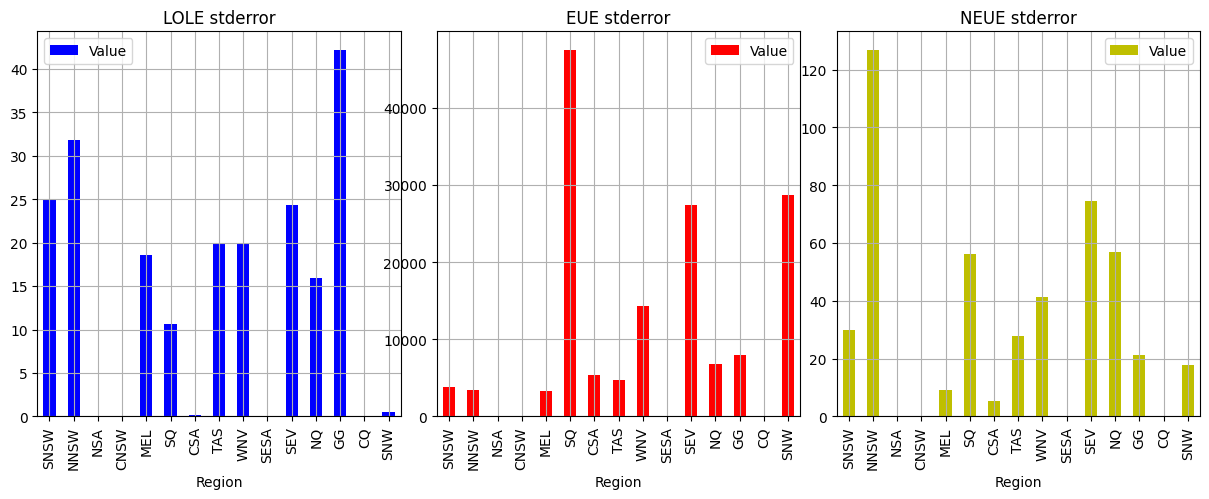

In [3]:
print("Scenario: ", scenario)
plot_std_error(error_dict)

Scenario:  ST


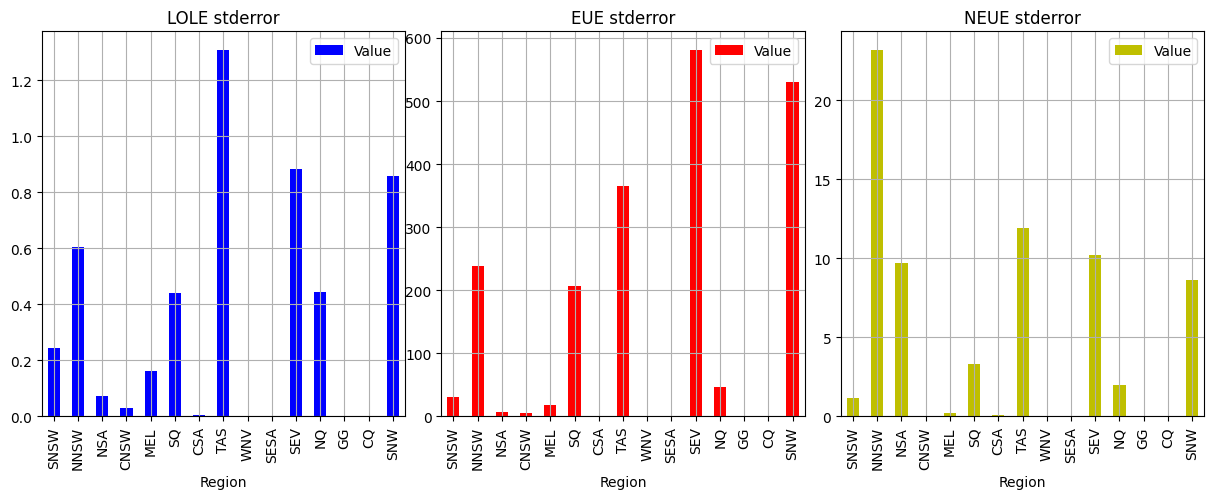

In [103]:
print("Scenario: ", scenario)
plot_std_error(error_dict)

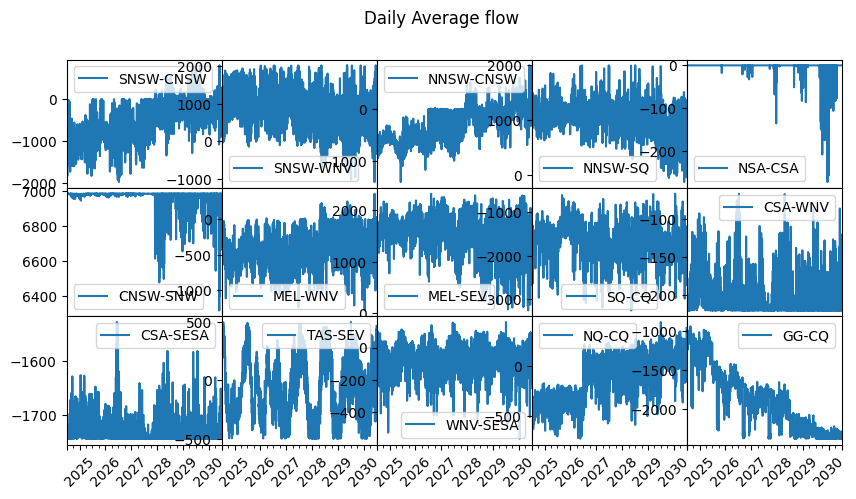

In [3]:
mean_flow, std_flow = load_scenario_data(scenario, IDIR, area_code_region)

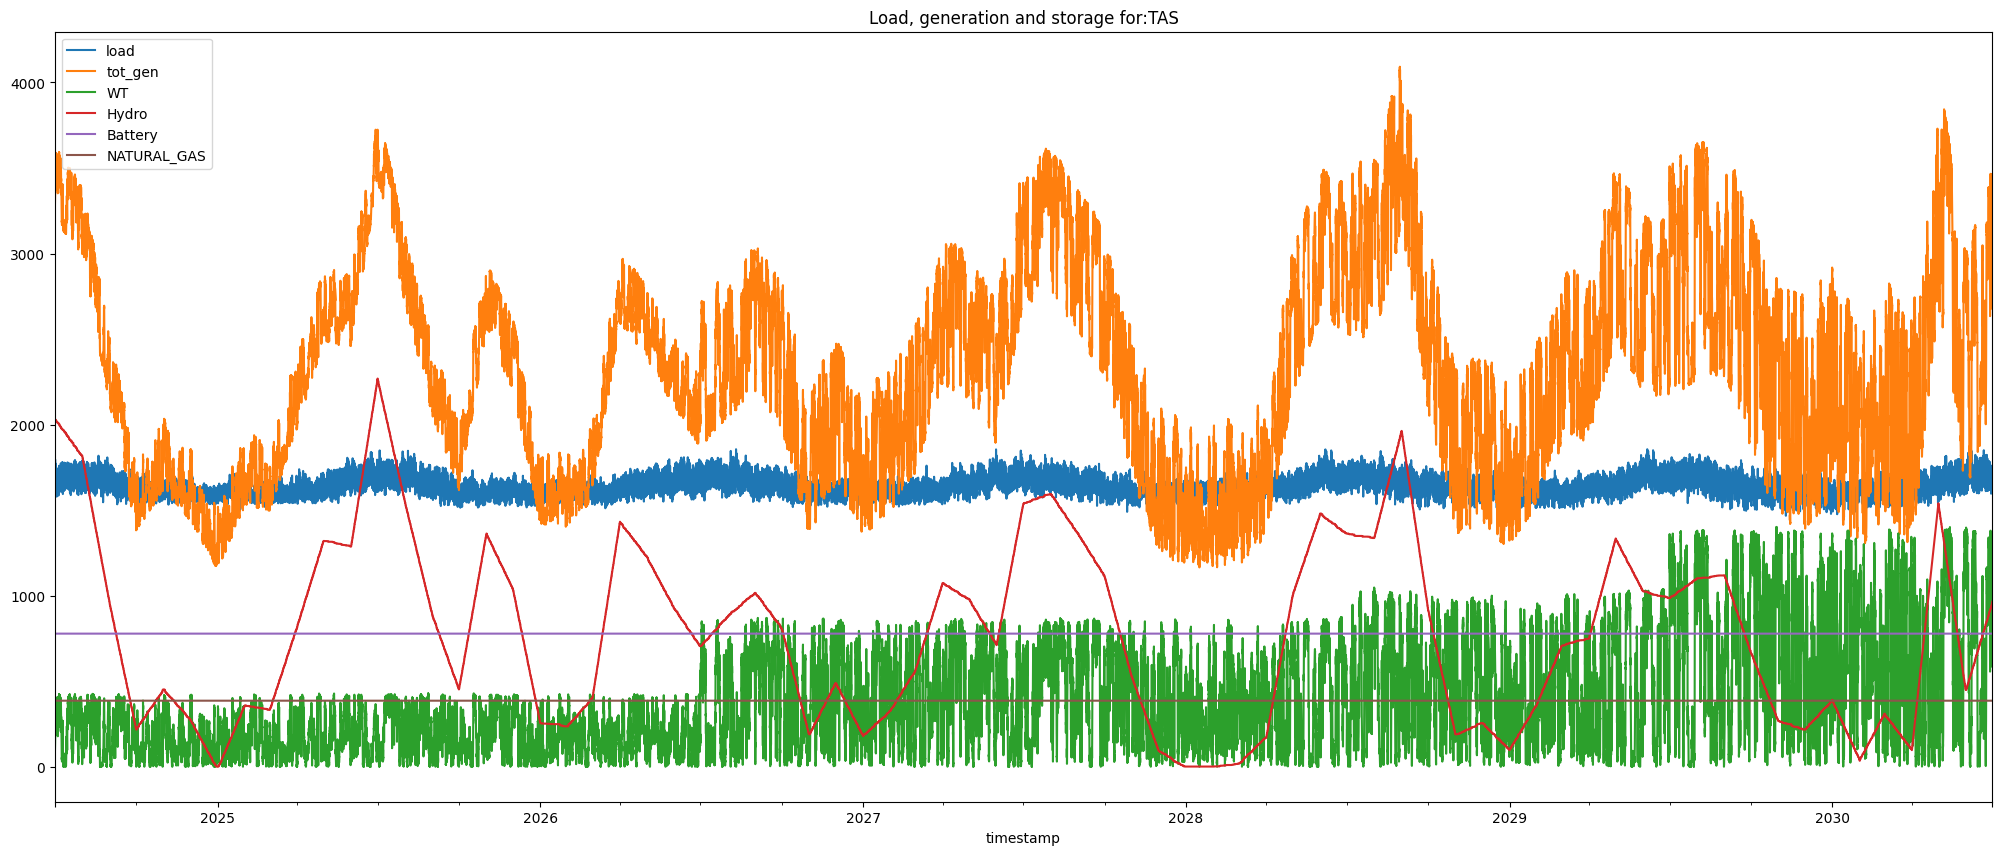

In [6]:
target_region = "TAS" 
get_all_info(target_region, shortfall_data, area_code_region)

In [8]:

storage = pd.read_csv(os.path.join(IDIR, scenario, "pras_energy_storage_timeseries.csv"))
storage["timestamp"] = pd.to_datetime(storage["timestamp"])
storage = storage.set_index("timestamp")
eue_df = load_eue_shortfall(area_code_region, scenario, IDIR)

<Axes: xlabel='timestamp'>

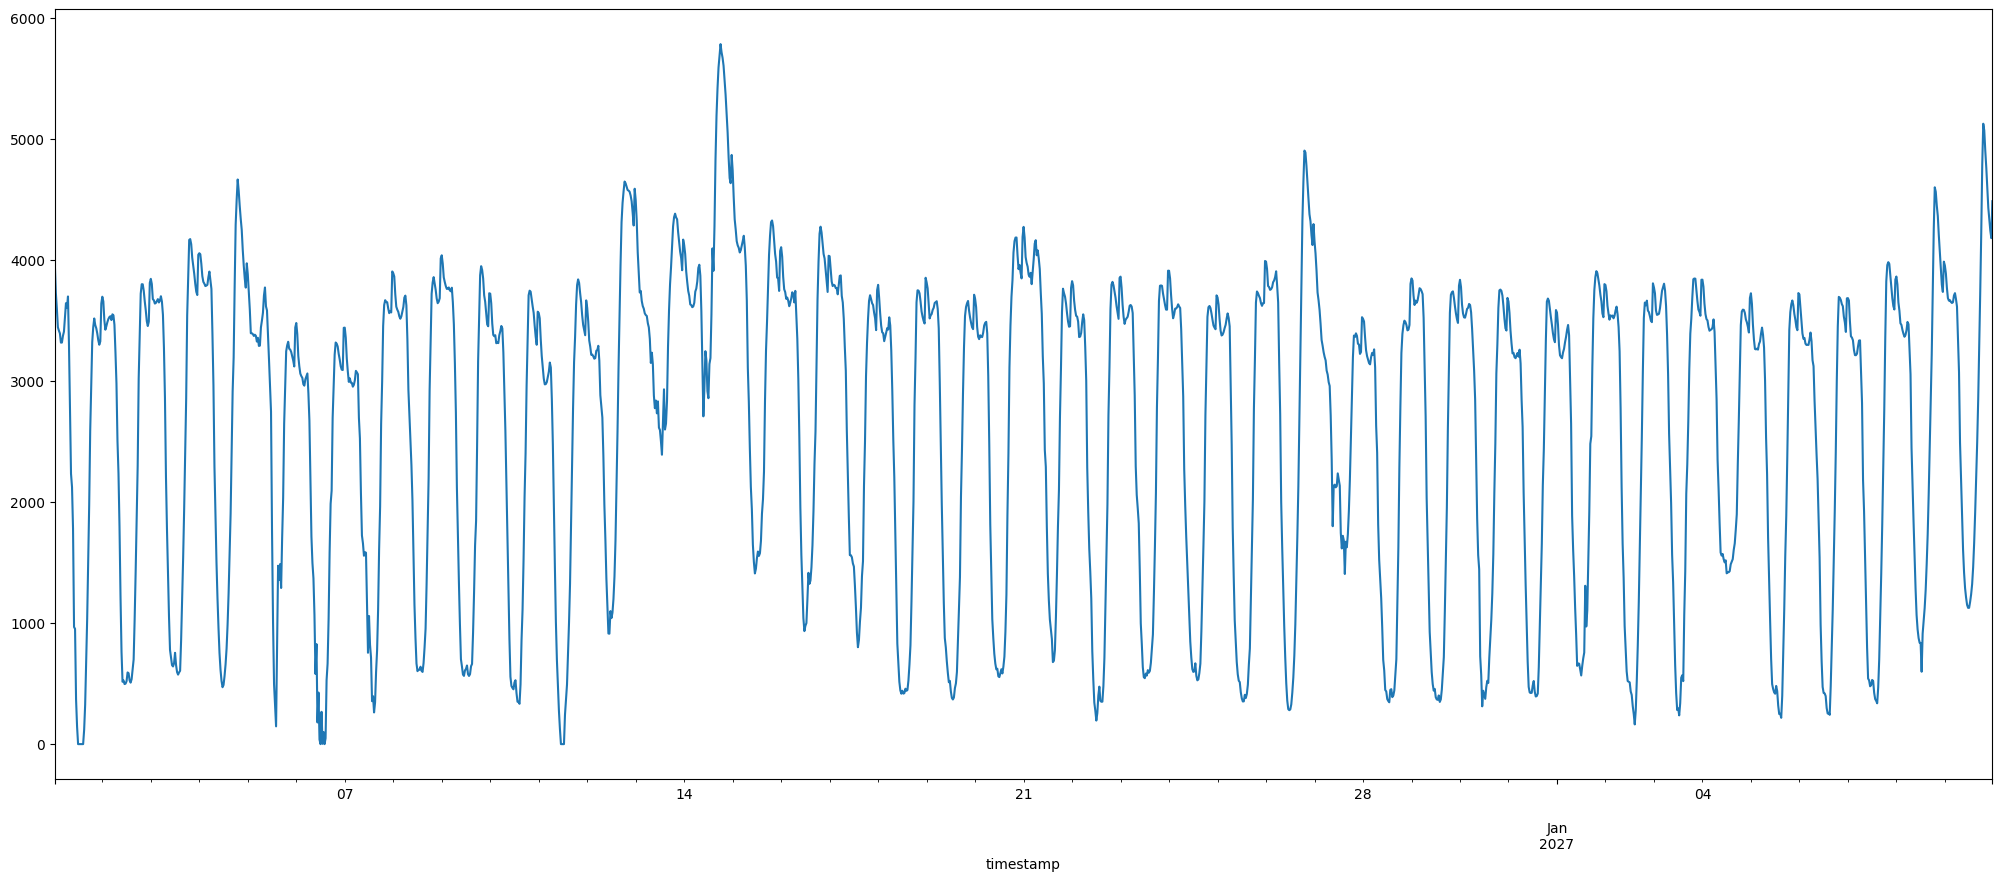

In [12]:
st_date = '2026-12-1'
en_date = '2027-01-10'
fig, ax1 = plt.subplots(figsize=figsize, nrows=1, ncols=1)
eue_df[(eue_df.index > st_date) & (eue_df.index < en_date)]["CSA"].plot(ax=ax1)

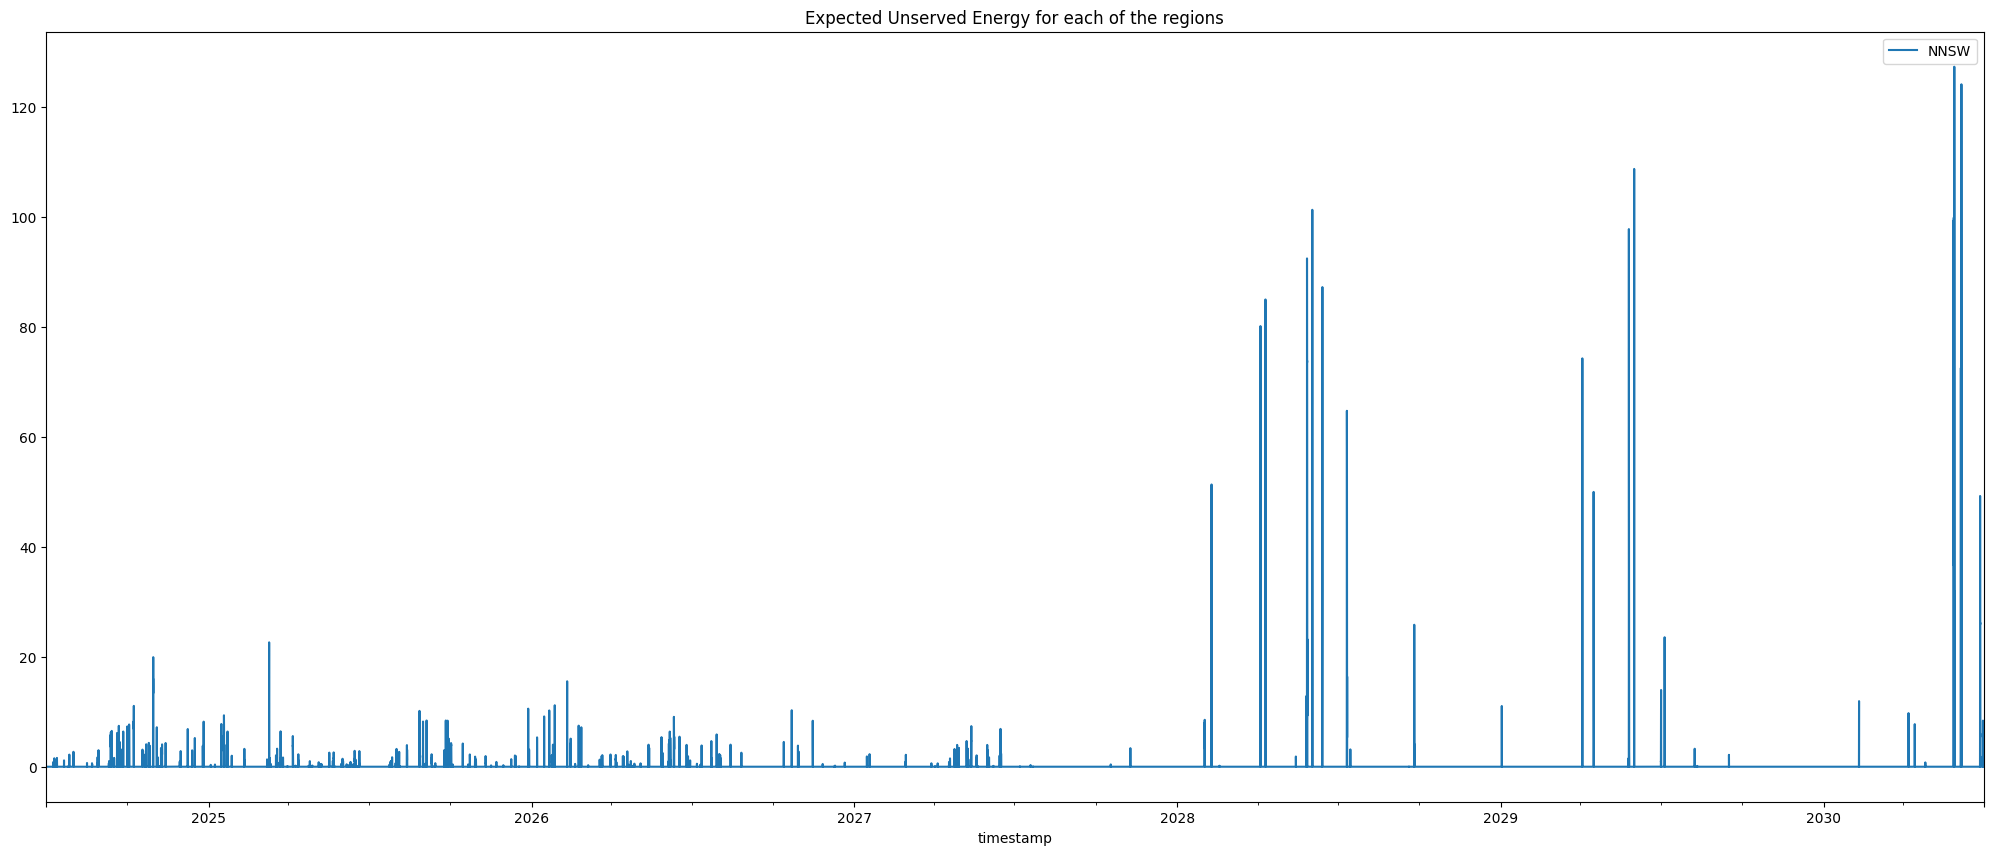

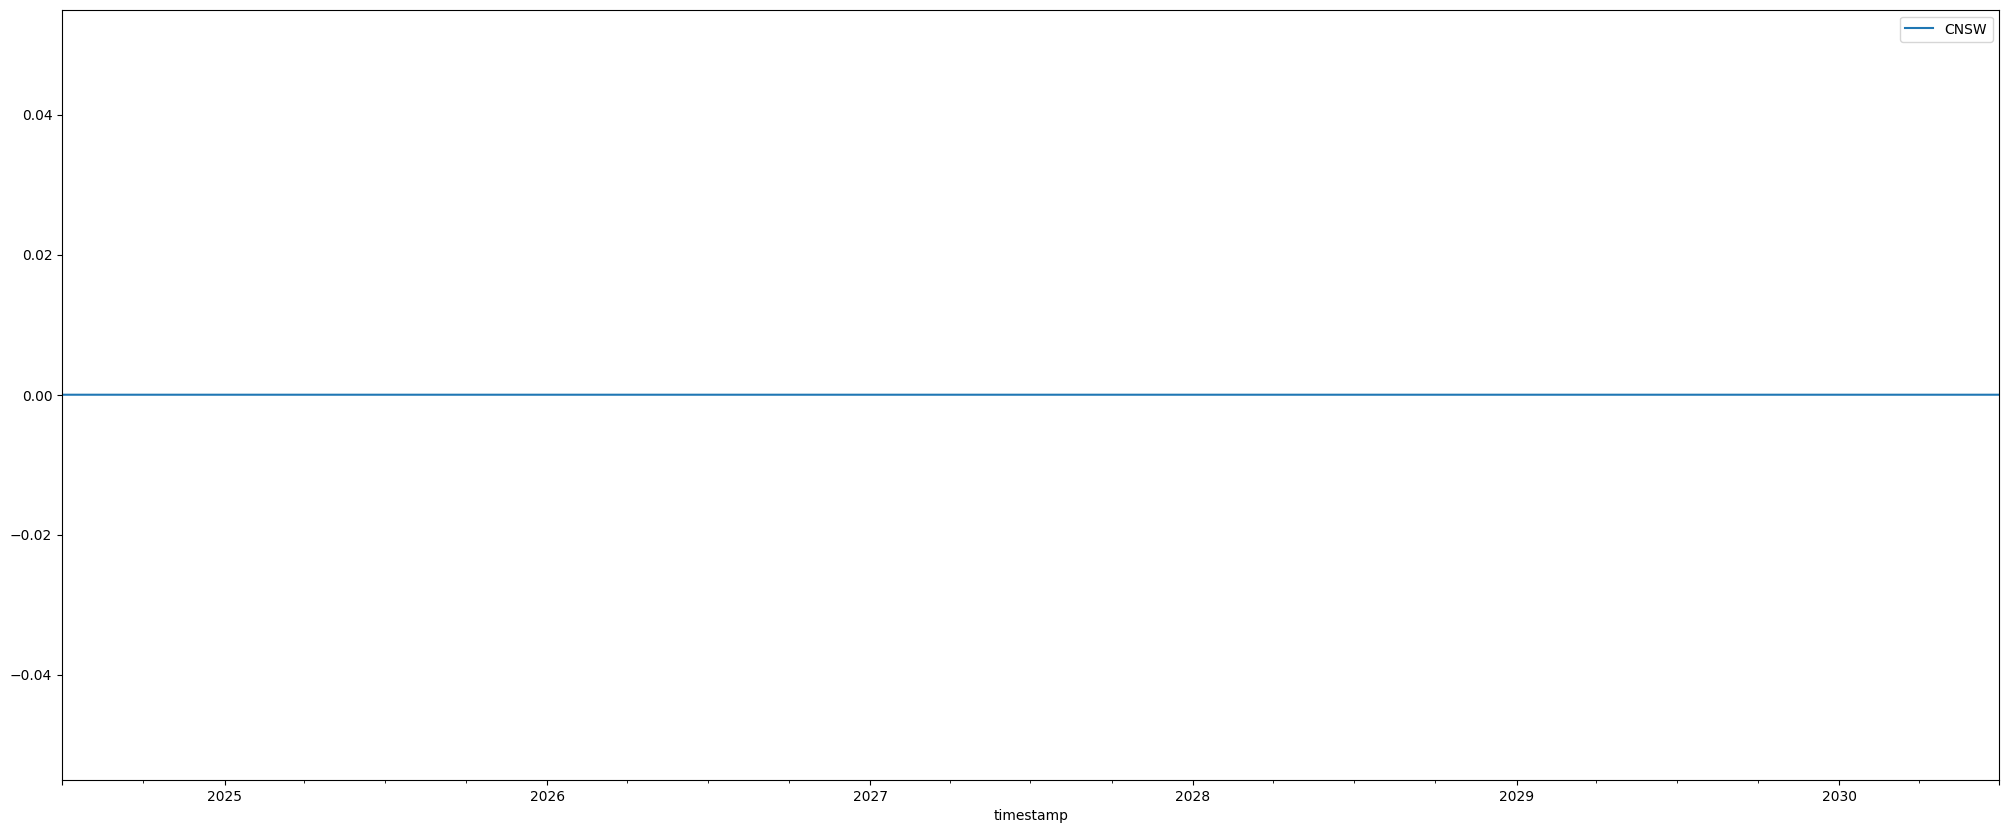

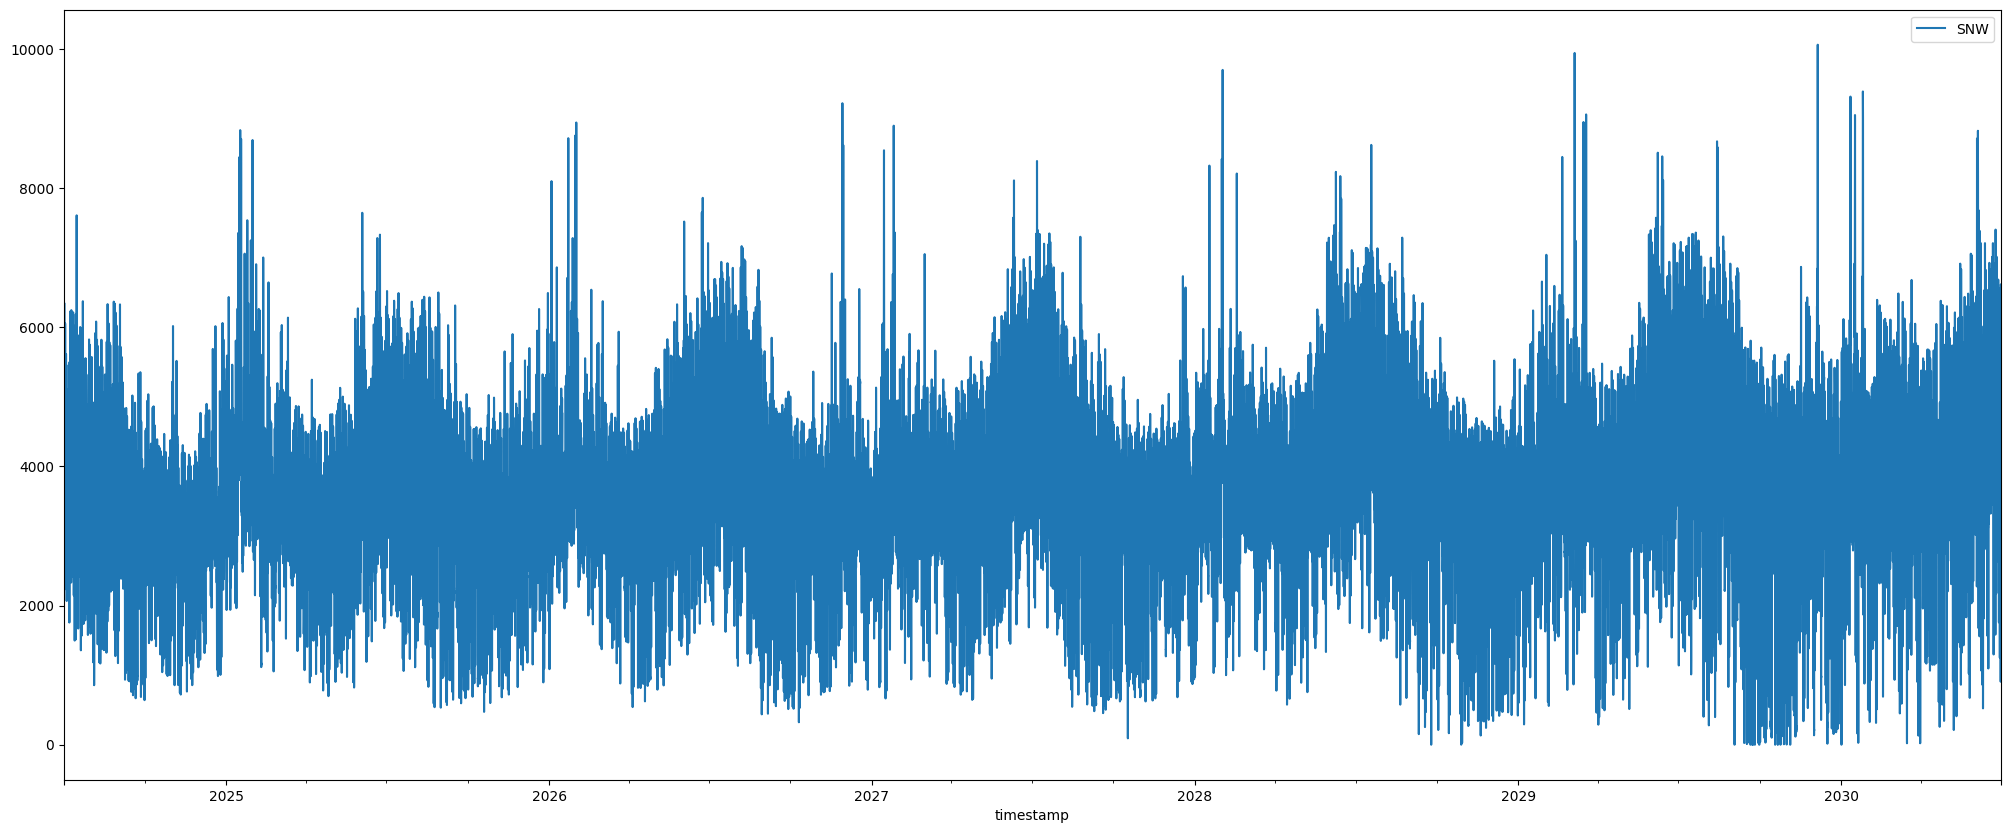

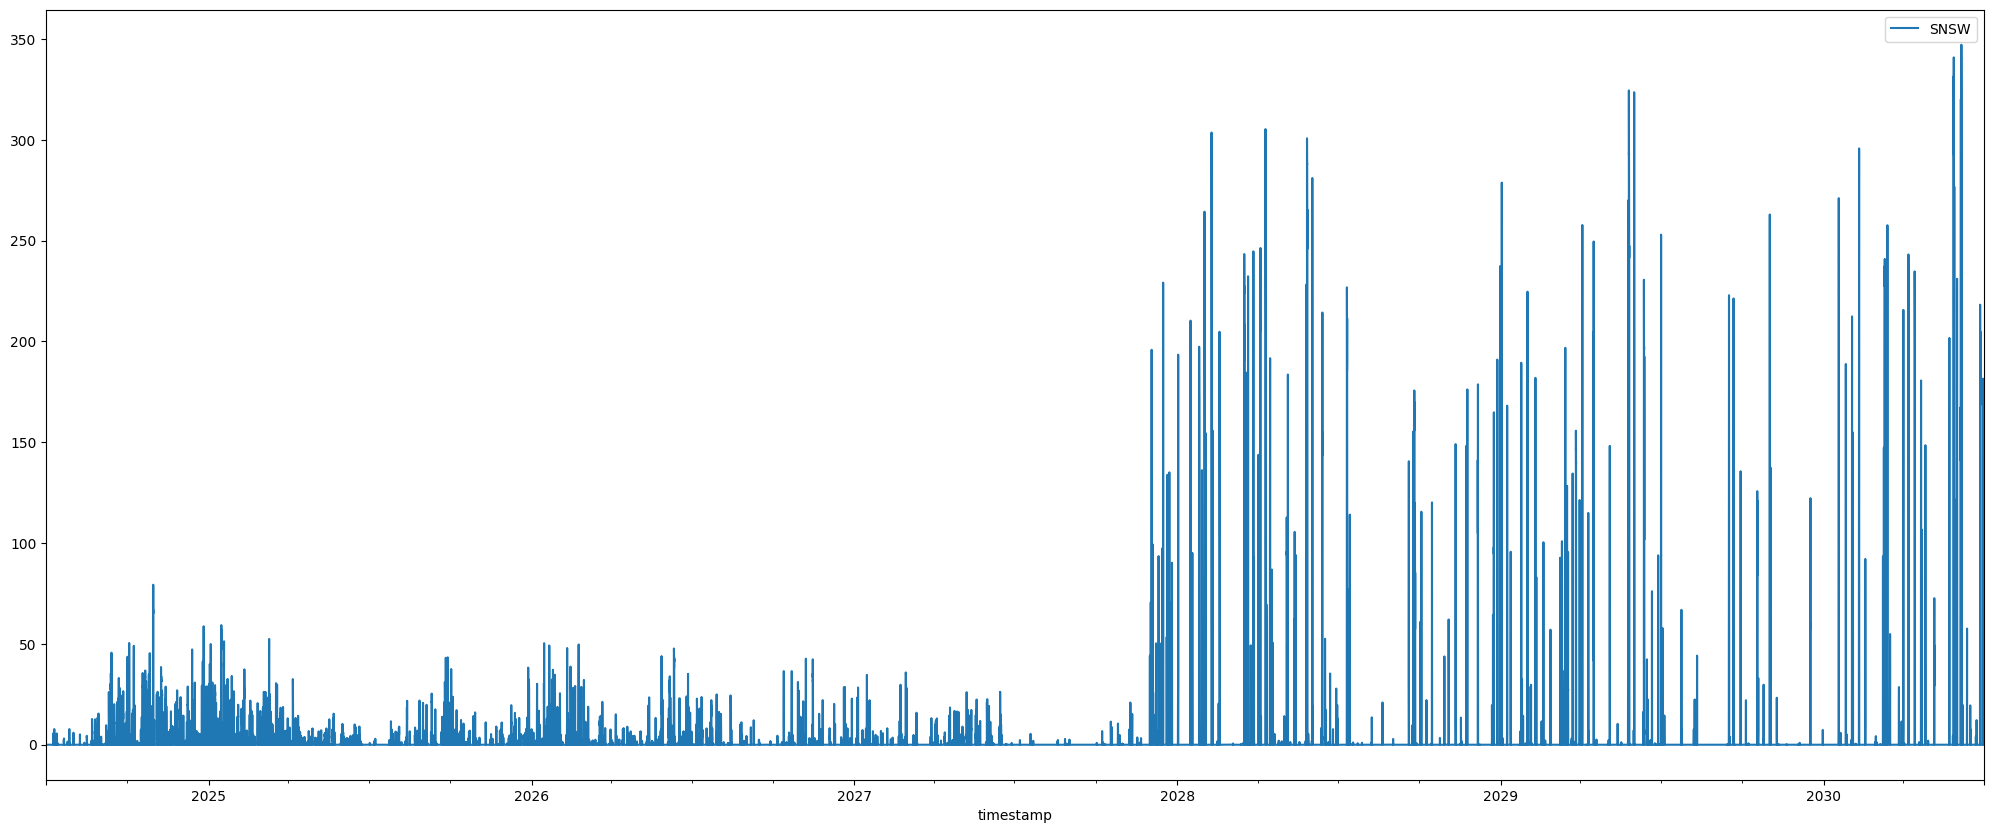

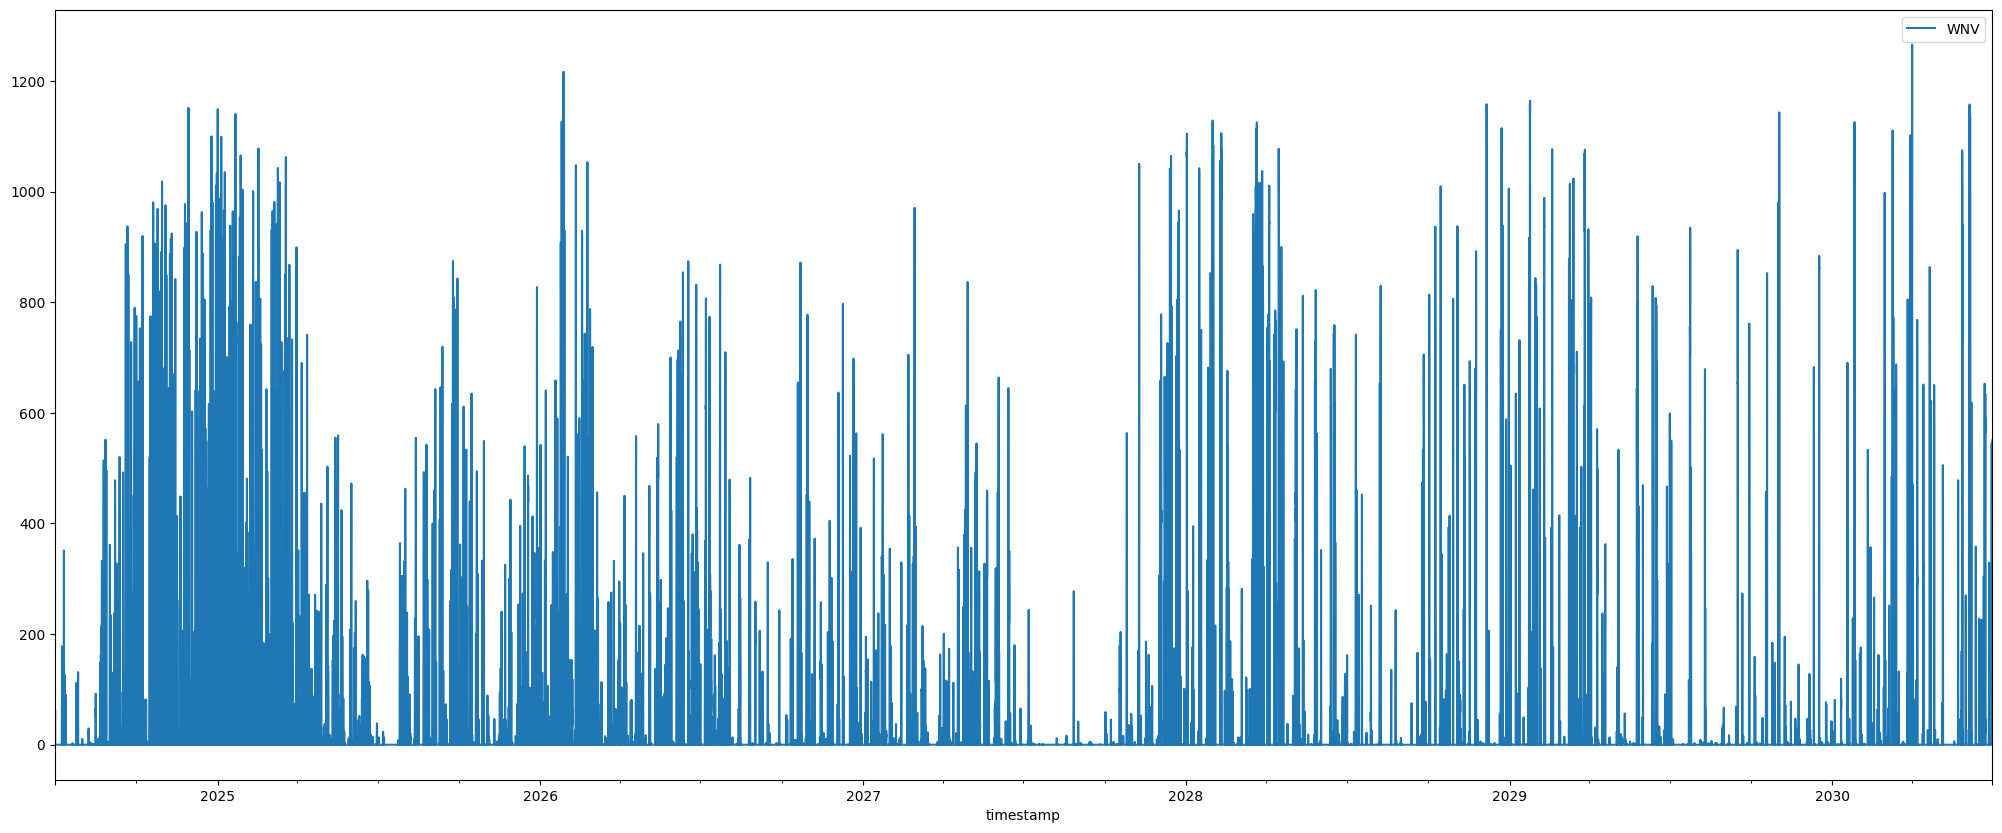

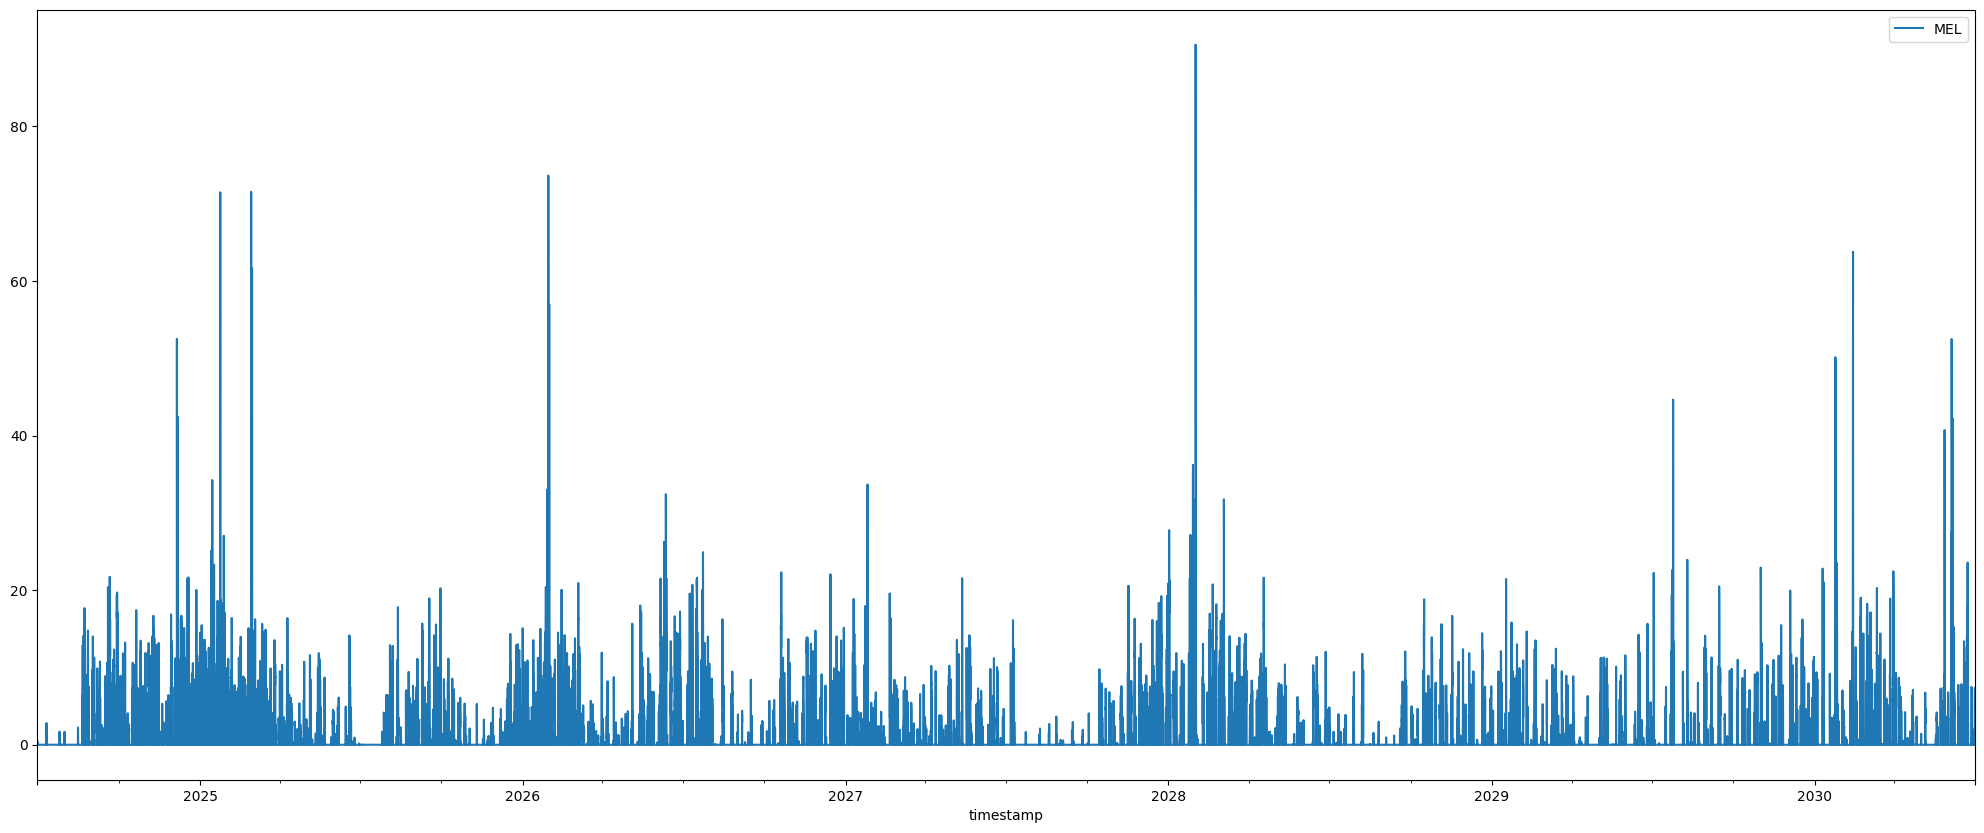

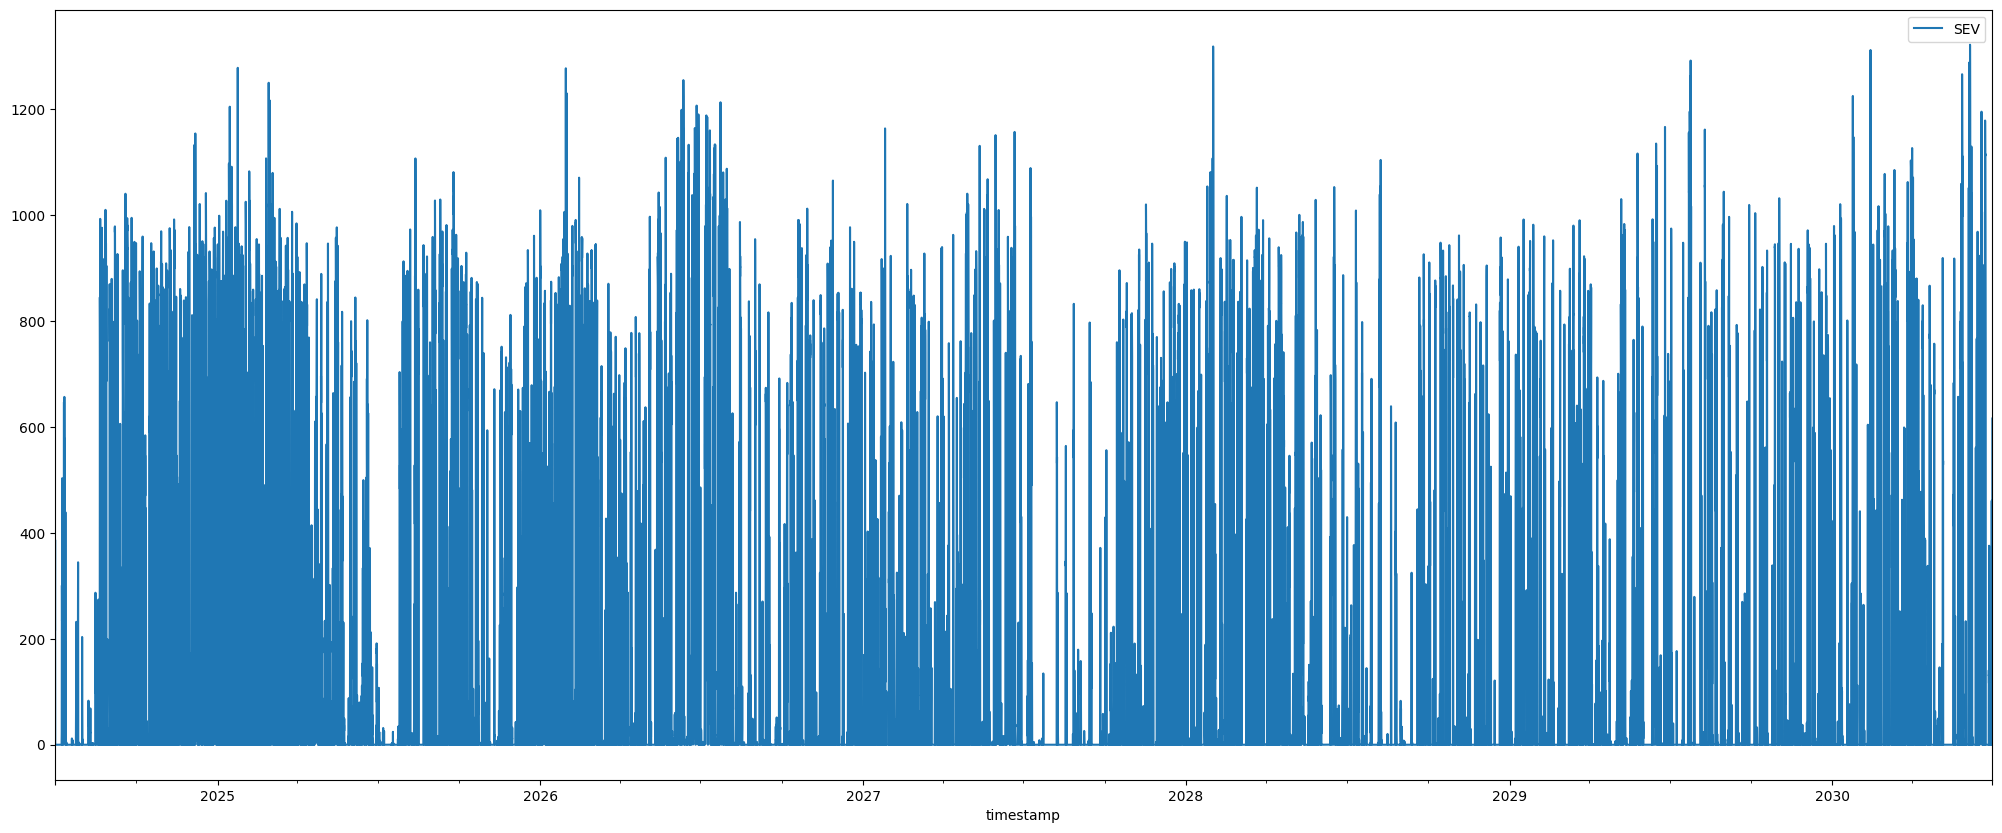

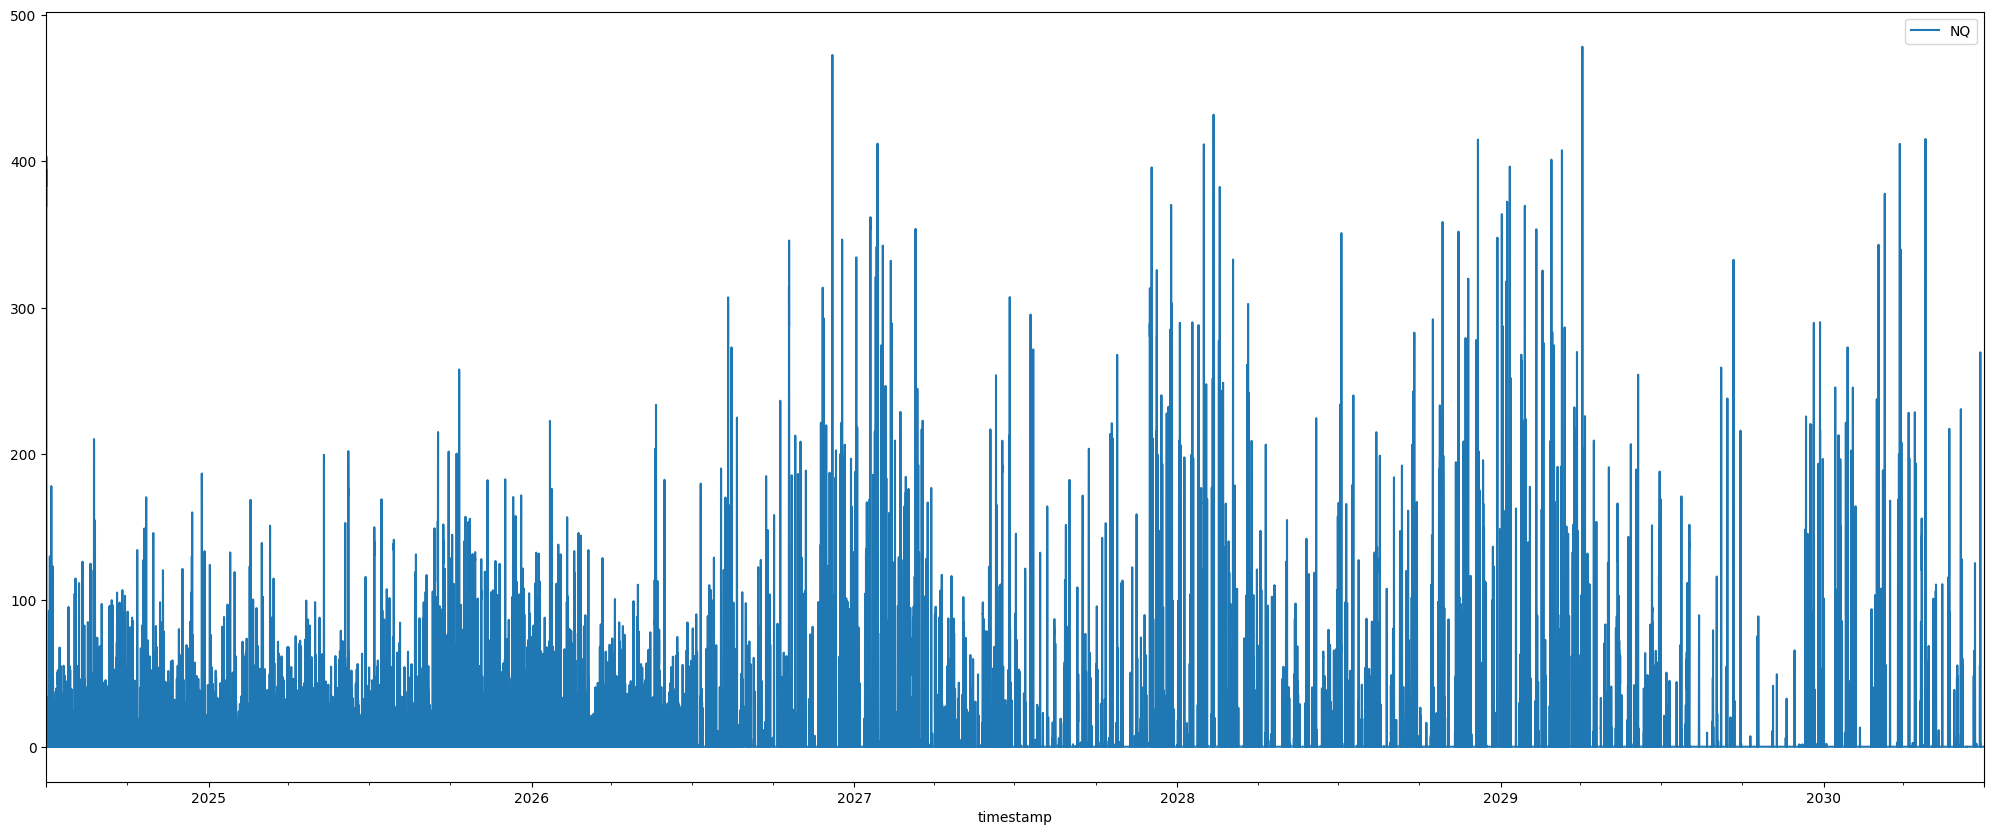

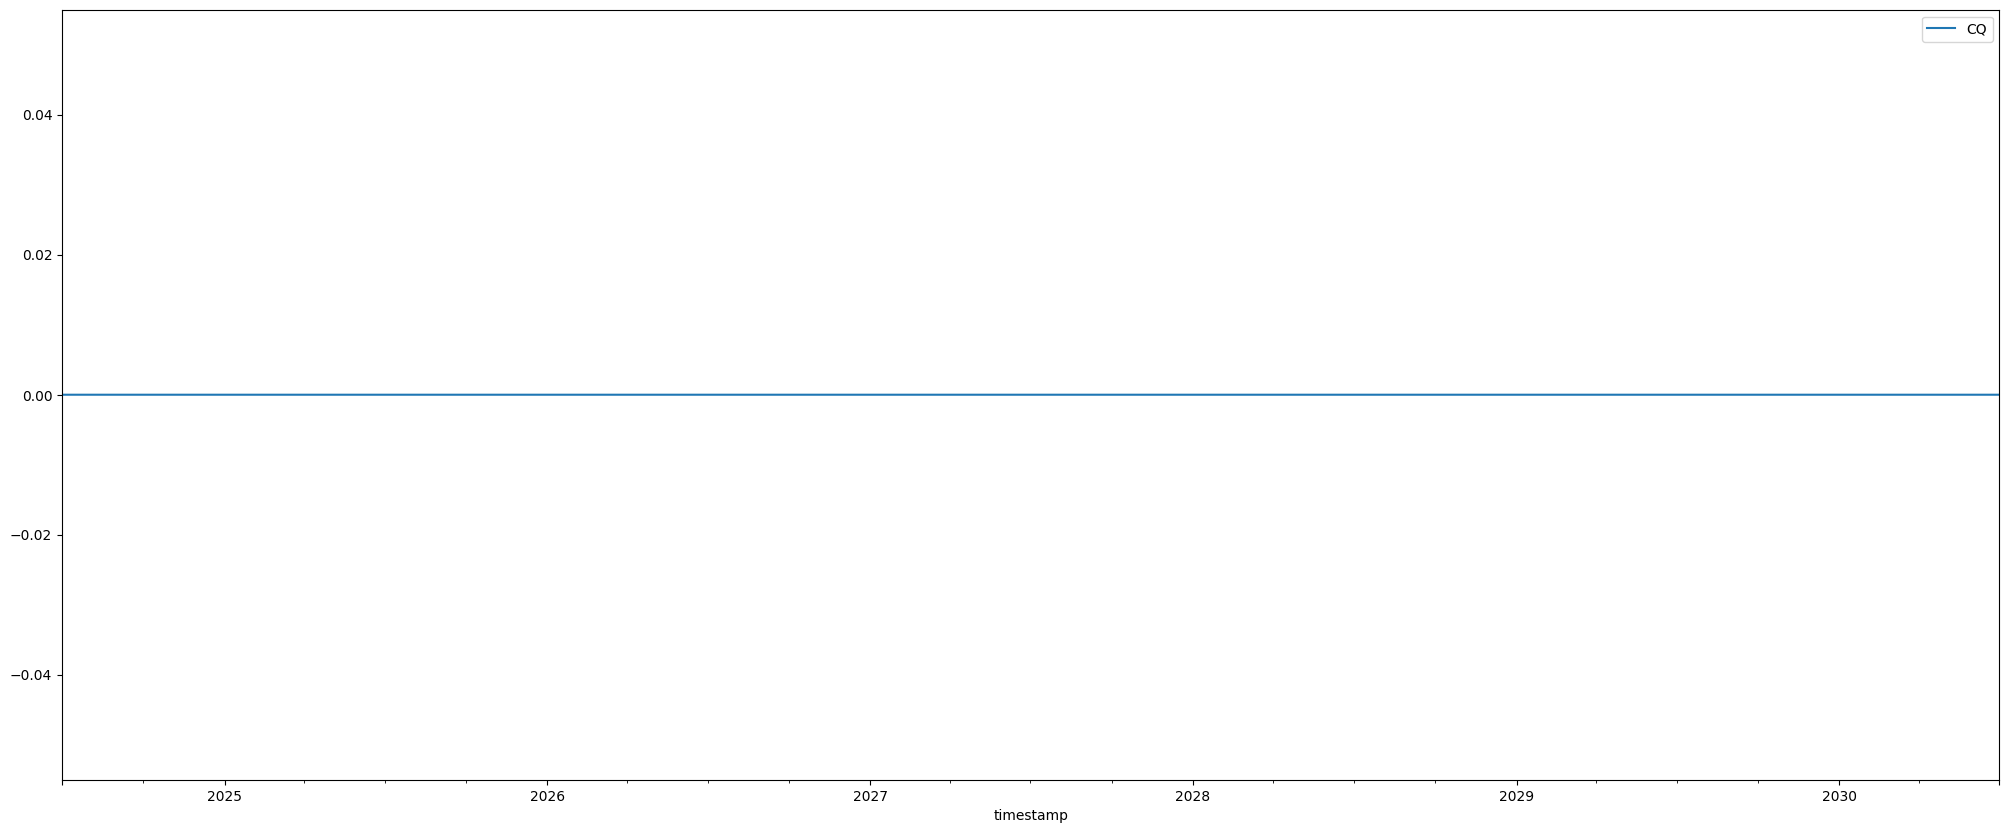

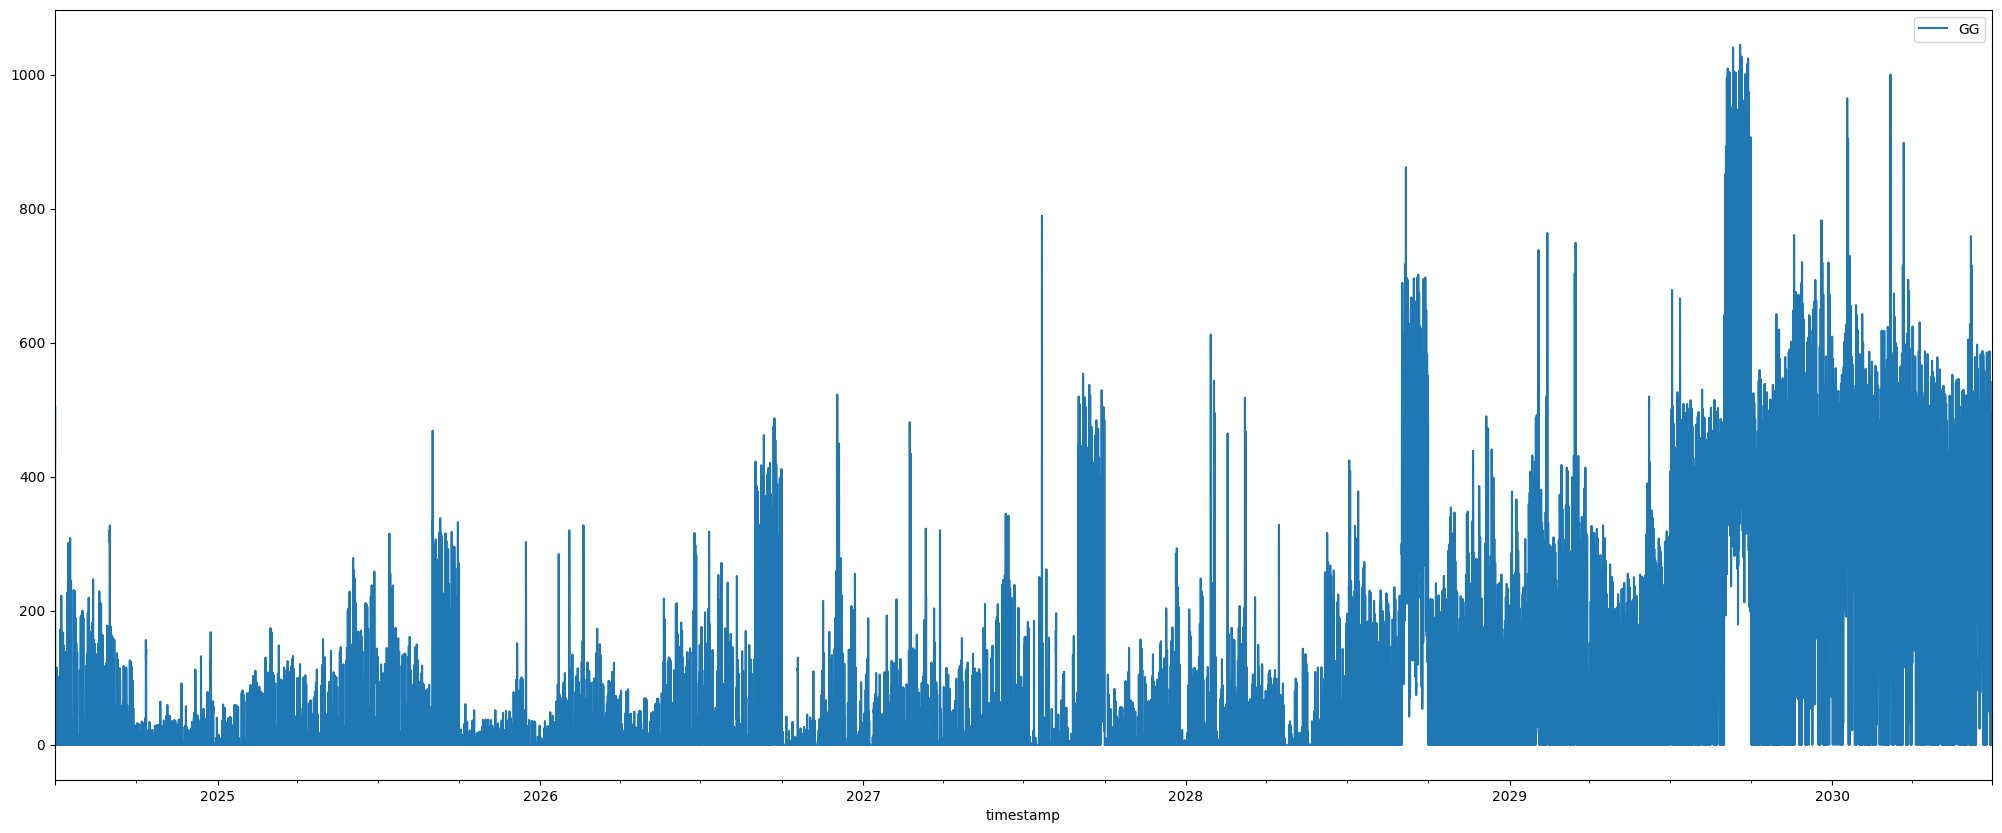

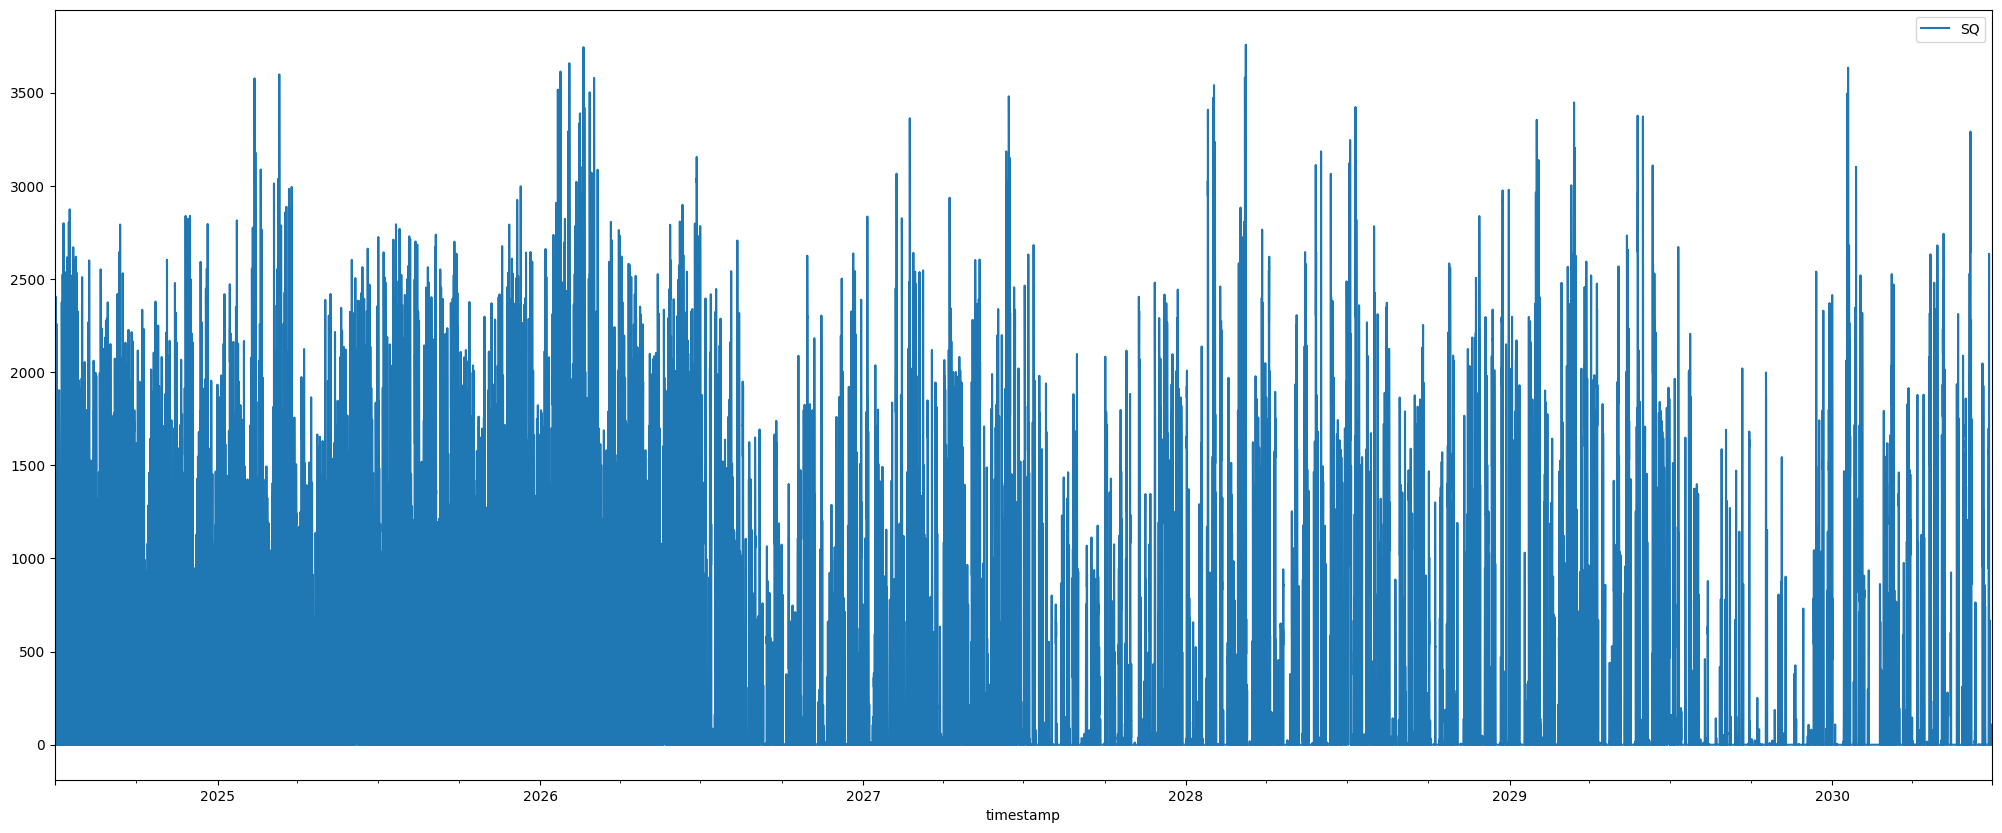

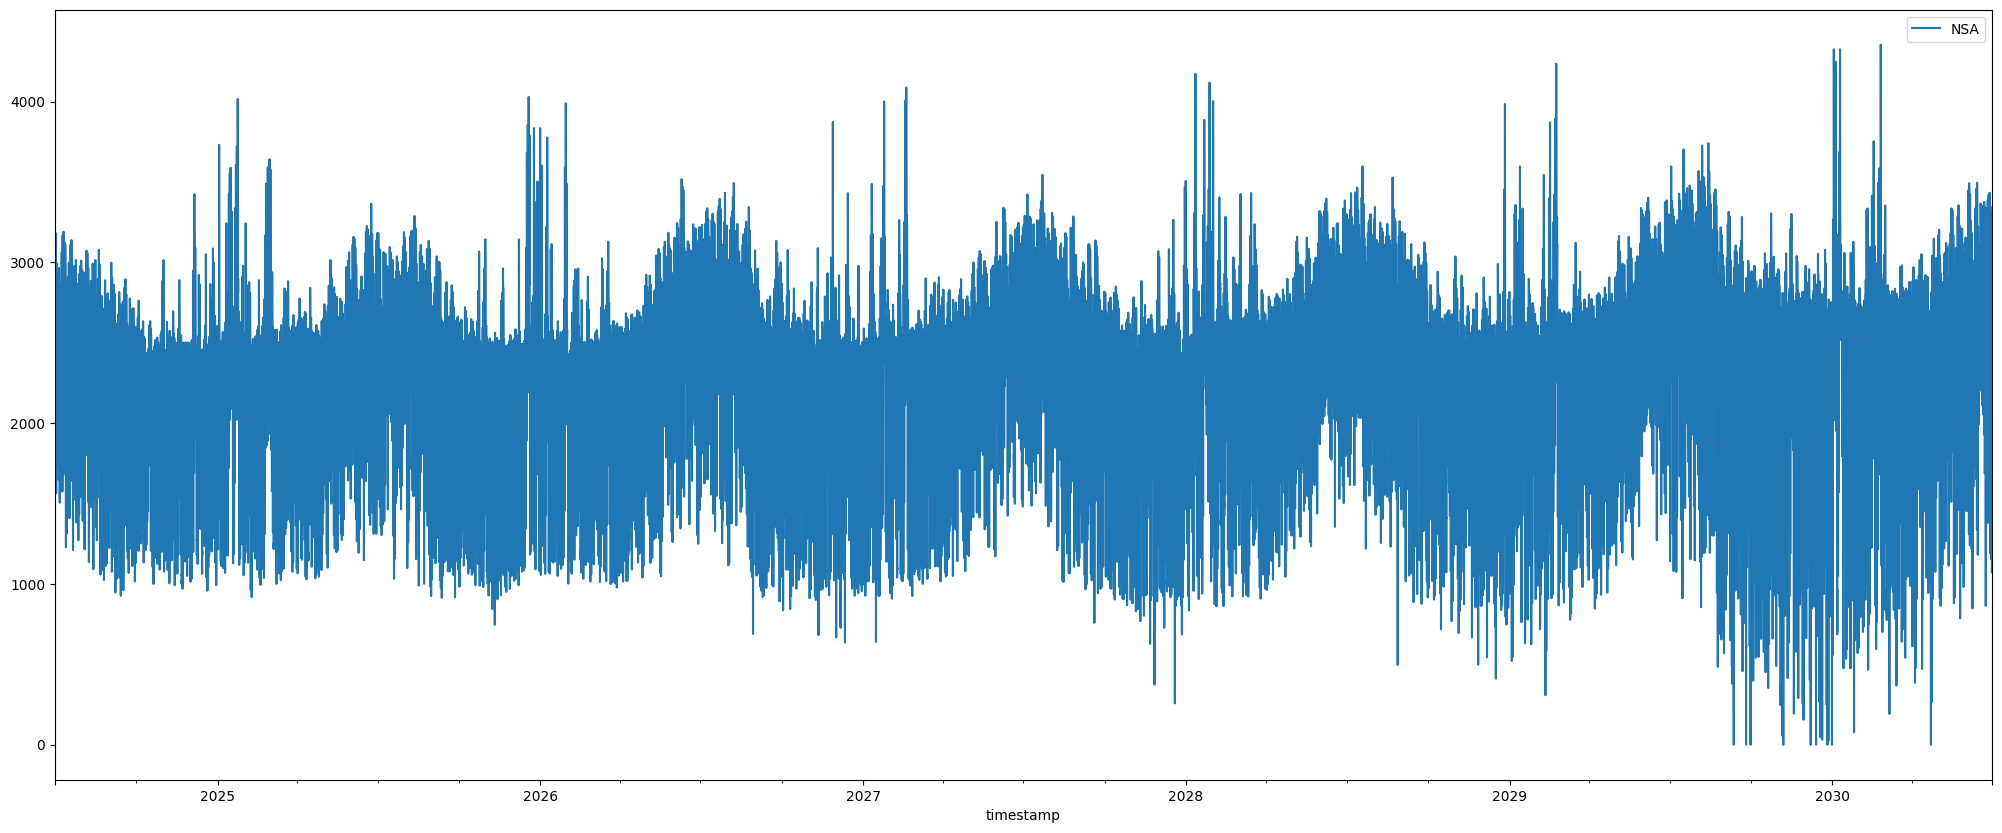

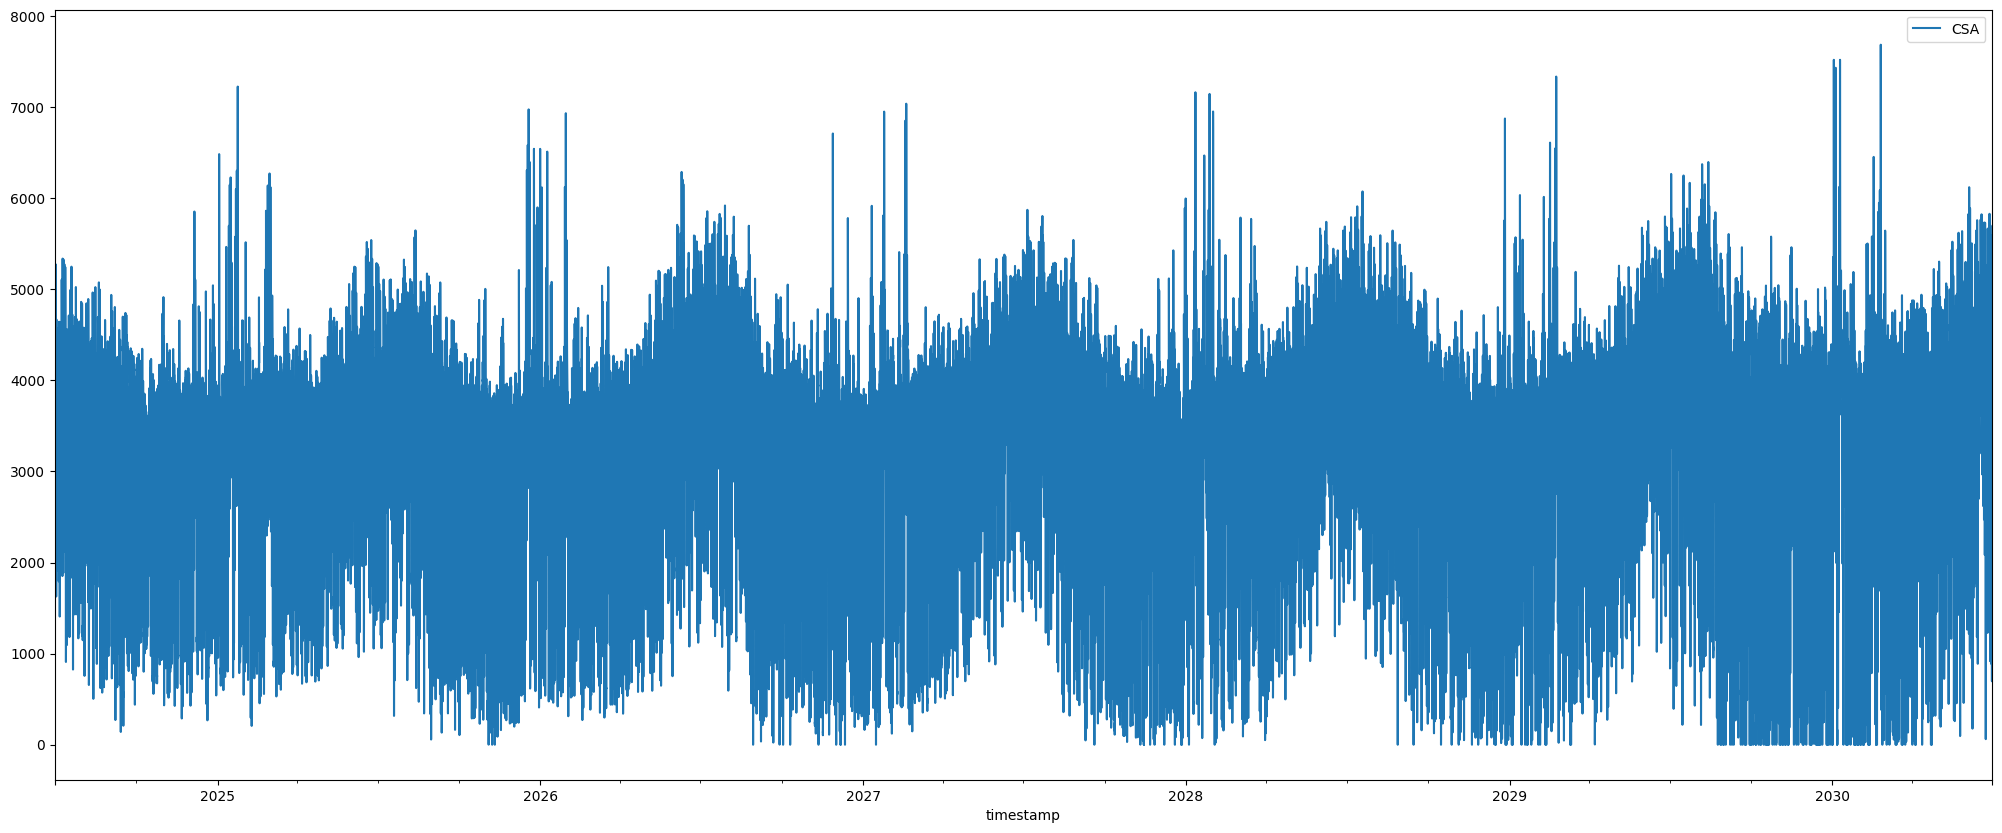

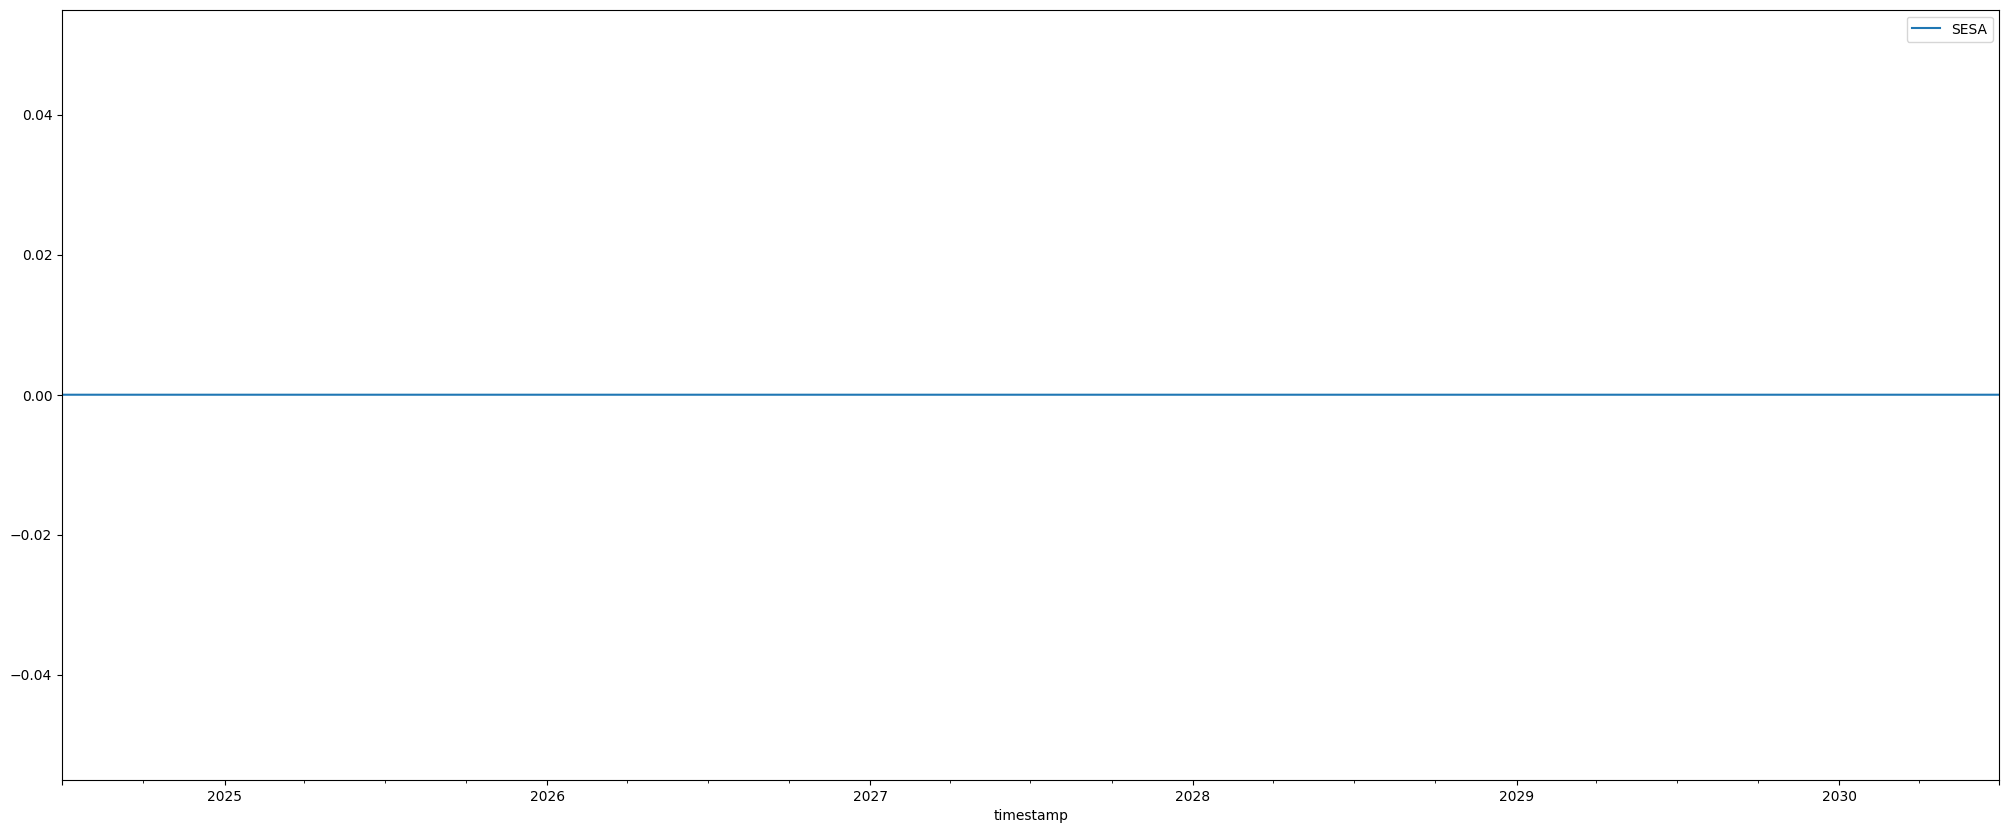

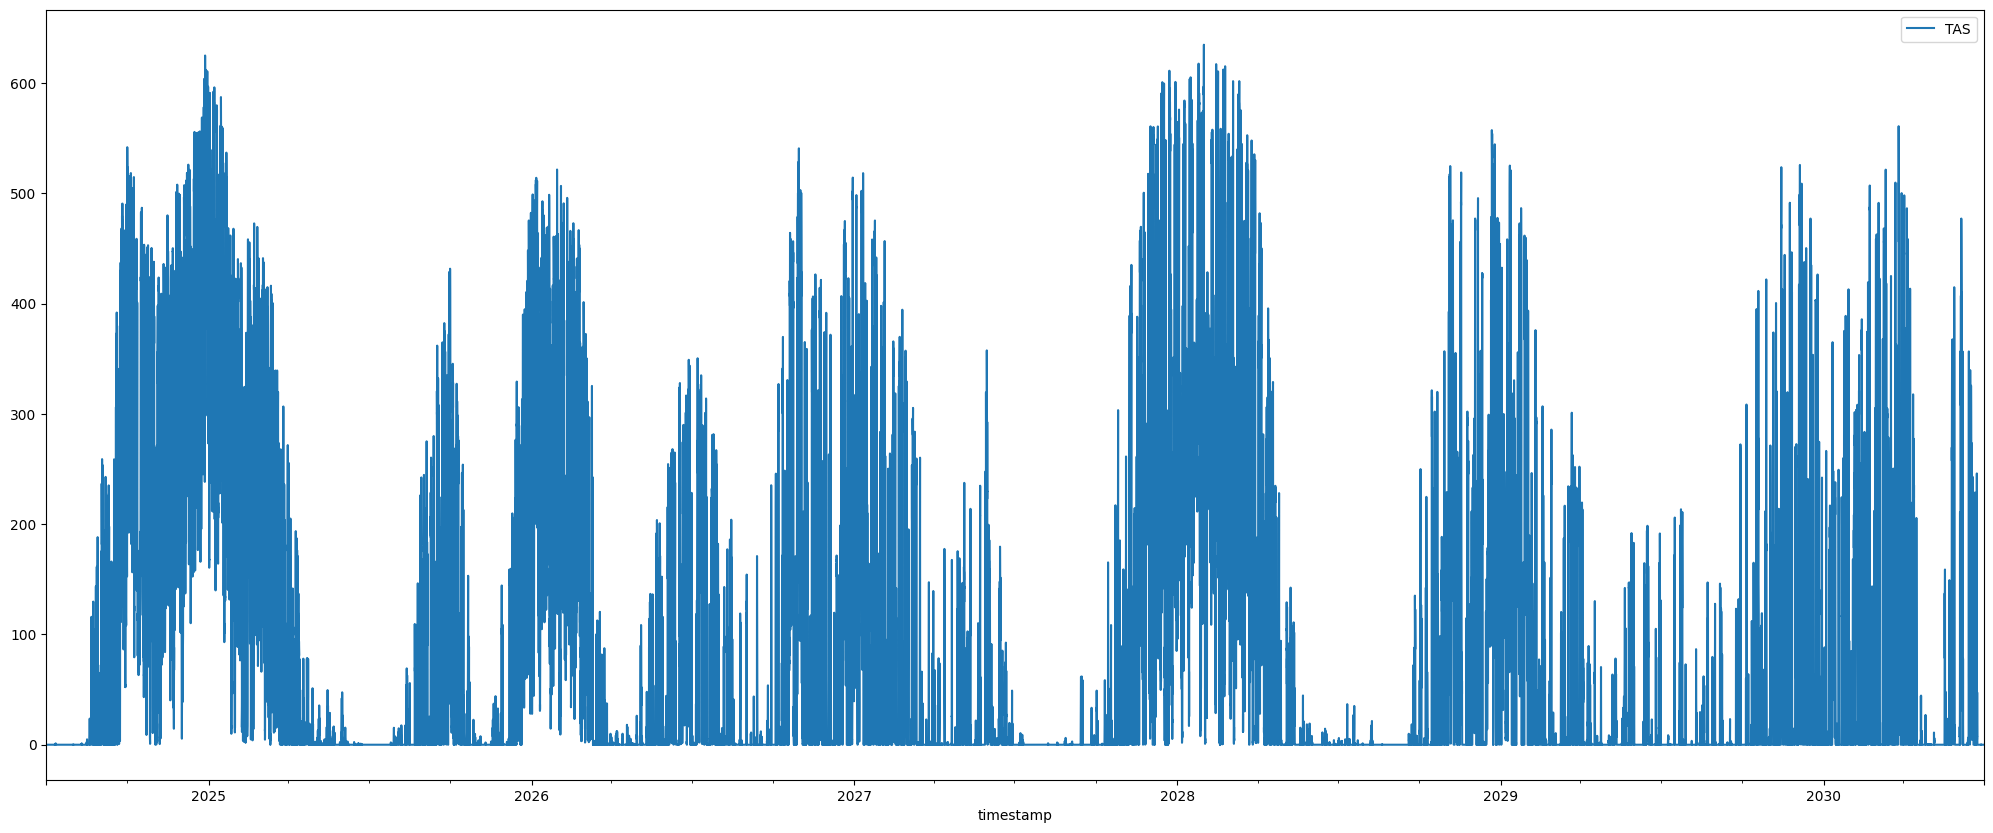

In [9]:
for i, kk in enumerate(eue_df.columns):
    fig, ax1 = plt.subplots(figsize=figsize, nrows=1, ncols=1)
    eue_df[kk].plot(ax=ax1, legend=True)
    if i == 0:
        ax1.set_title("Expected Unserved Energy for each of the regions")

In [10]:
# available battery in the regions [13,  6, 11,  4,  8,  9,  2,  5,  7]
#flow_for = flow_result(scenario, area_code_region)
#max_EUE = find_max_eue_regions(area_code_region, eue_df)
#print("Maximum Expected Unserved Energy detected :\n", max_EUE)
#print("flow name available for: ", flow_for.columns.tolist())


### Flow name to chose
'SNSW-CNSW_mean_flow',
 'SNSW-WNV_mean_flow',
 'NNSW-CNSW_mean_flow',
 'NNSW-SQ_mean_flow',
 'NSA-CSA_mean_flow',
 'CNSW-SNW_mean_flow',
 'MEL-WNV_mean_flow',
 'MEL-SEV_mean_flow',
 'SQ-CQ_mean_flow',
 'CSA-WNV_mean_flow',
 'CSA-SESA_mean_flow',
 'TAS-SEV_mean_flow',
 'WNV-SESA_mean_flow',
 'NQ-CQ_mean_flow',
 'GG-CQ_mean_flow'


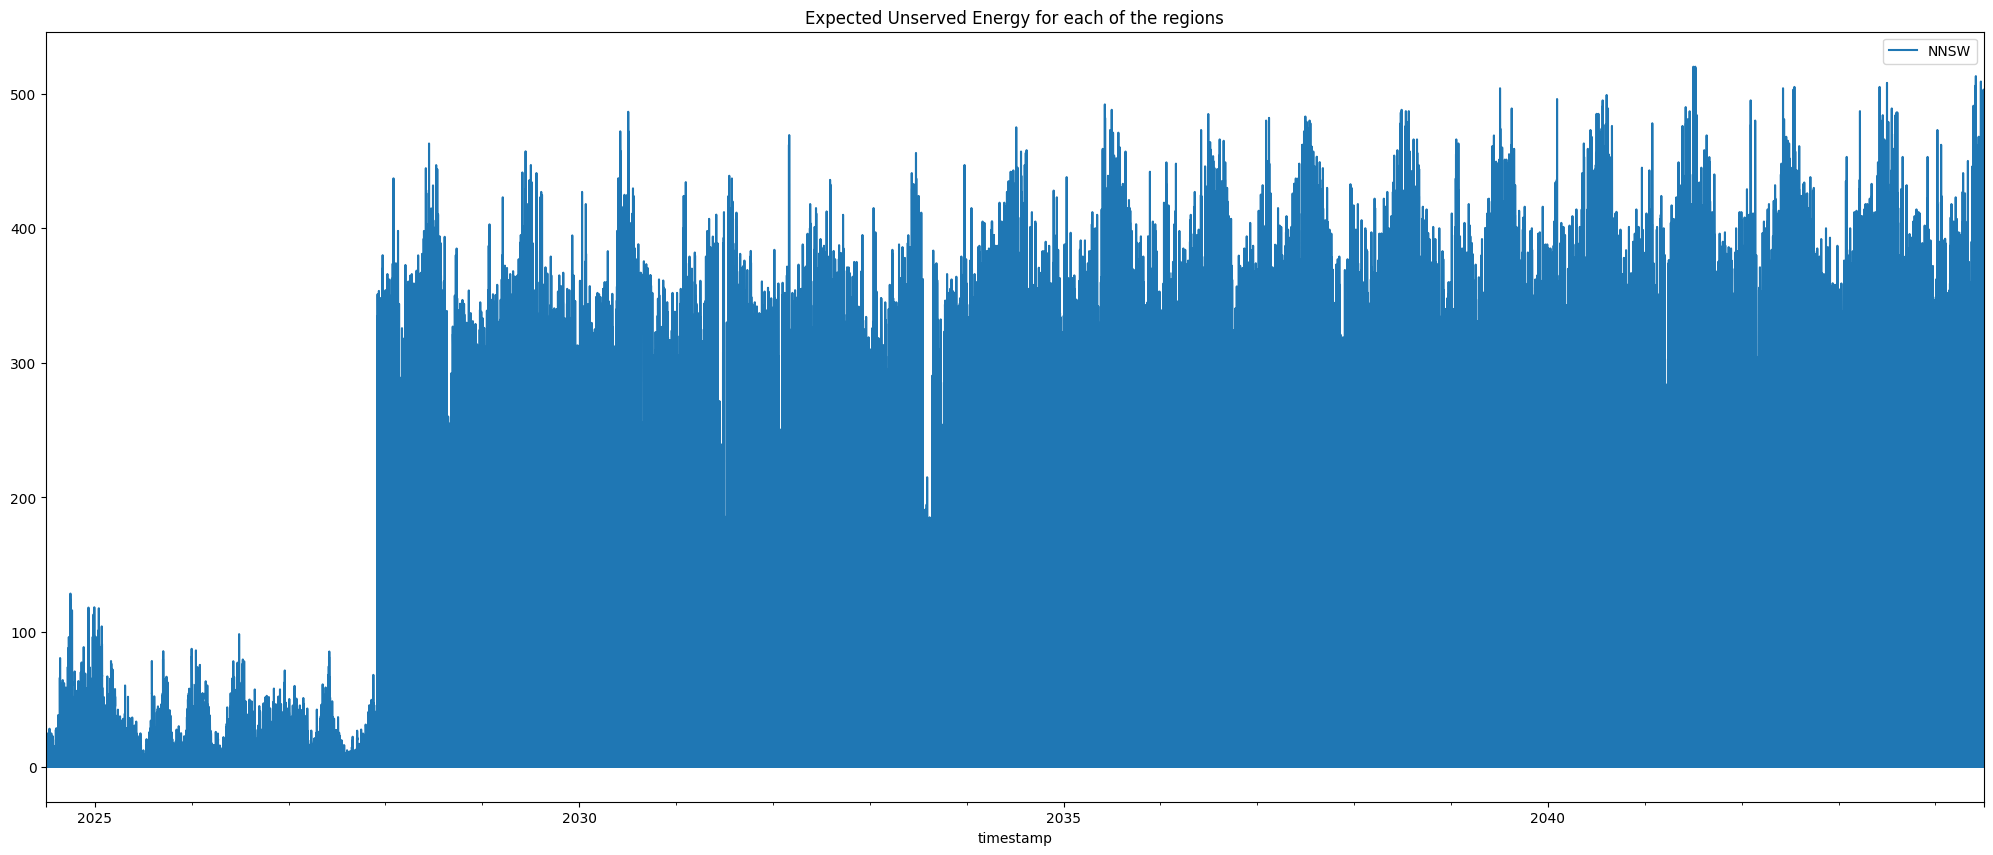

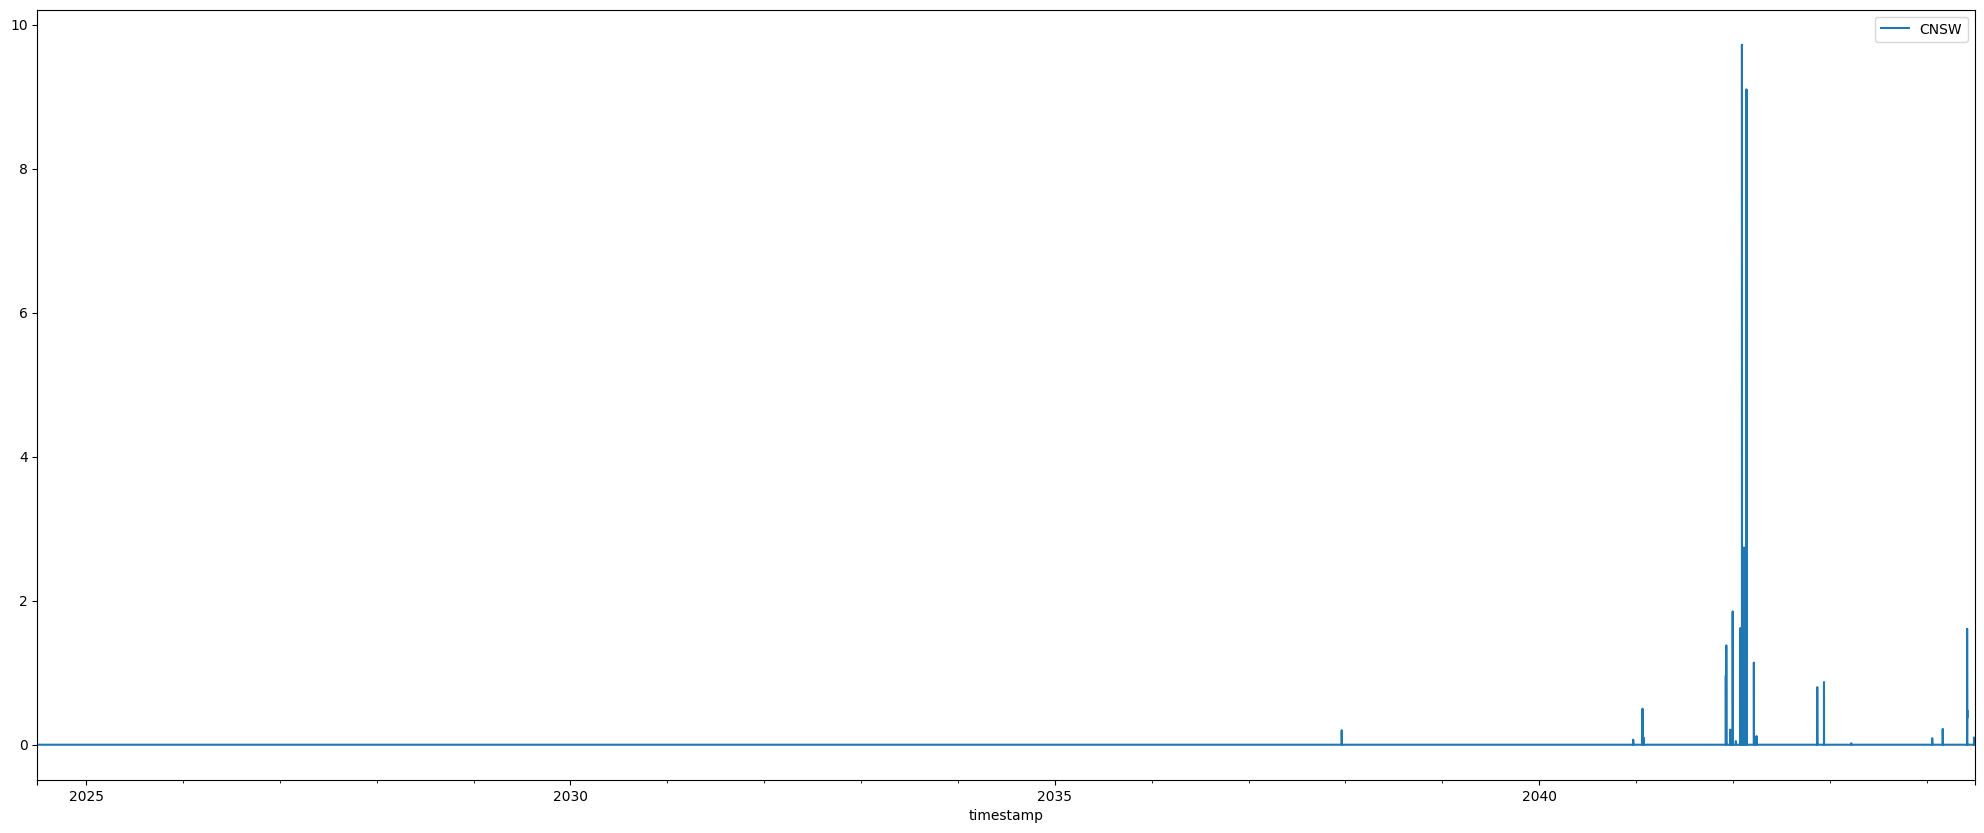

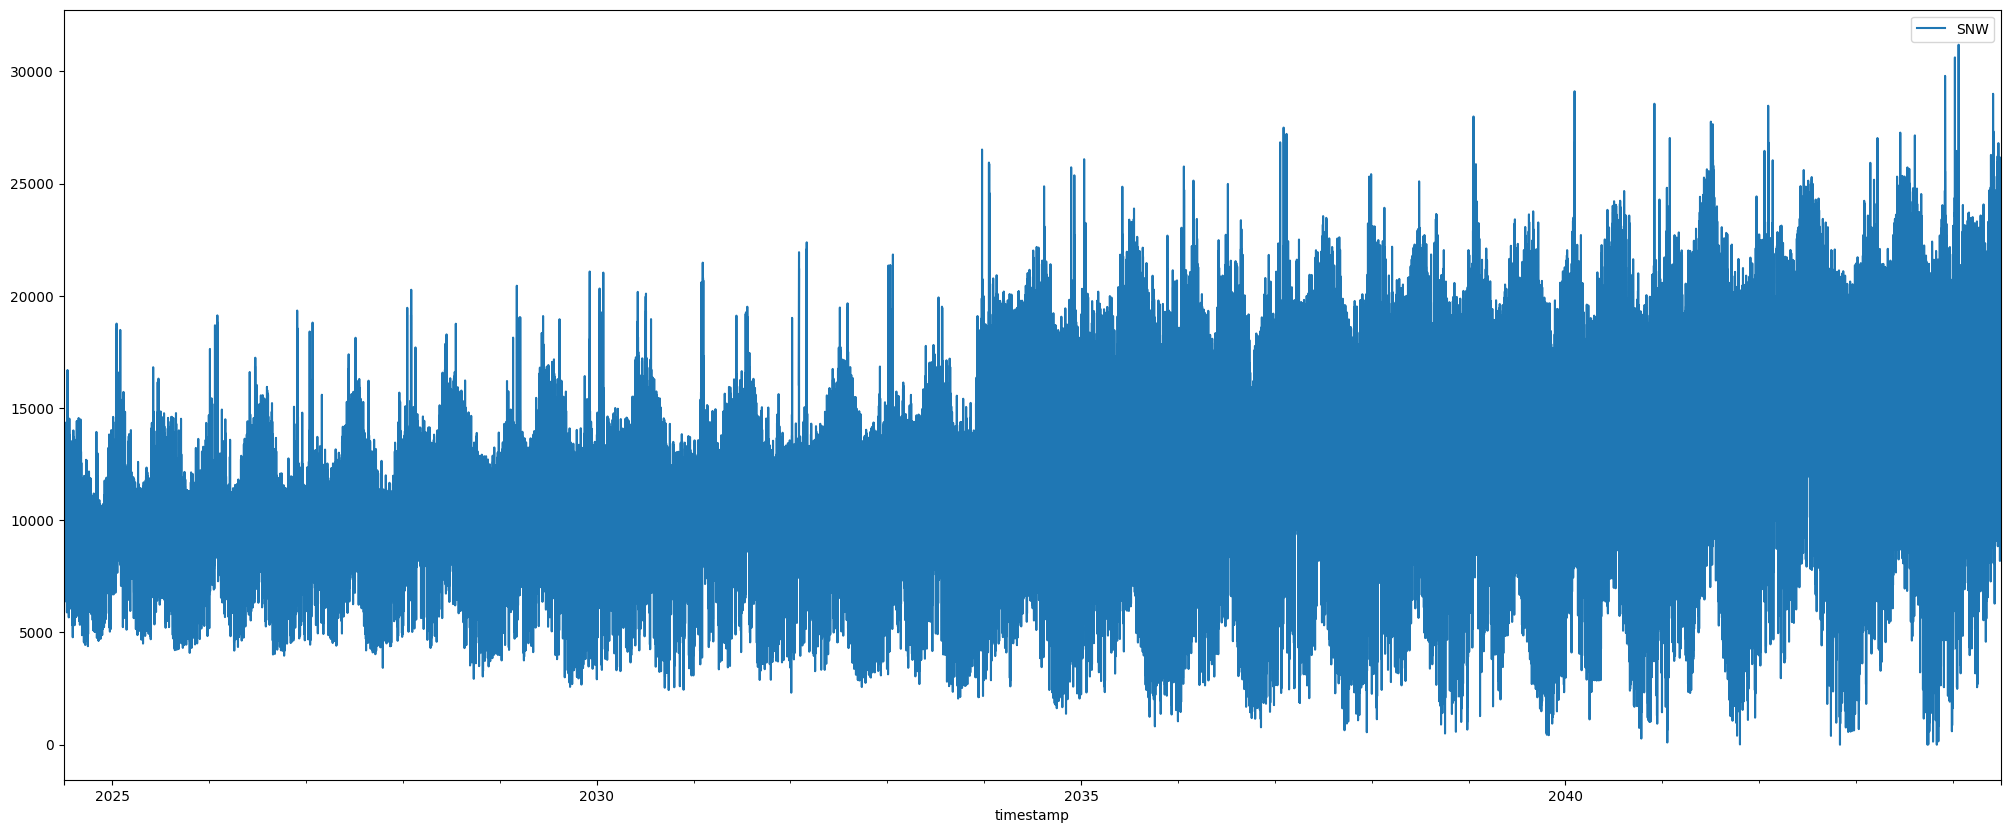

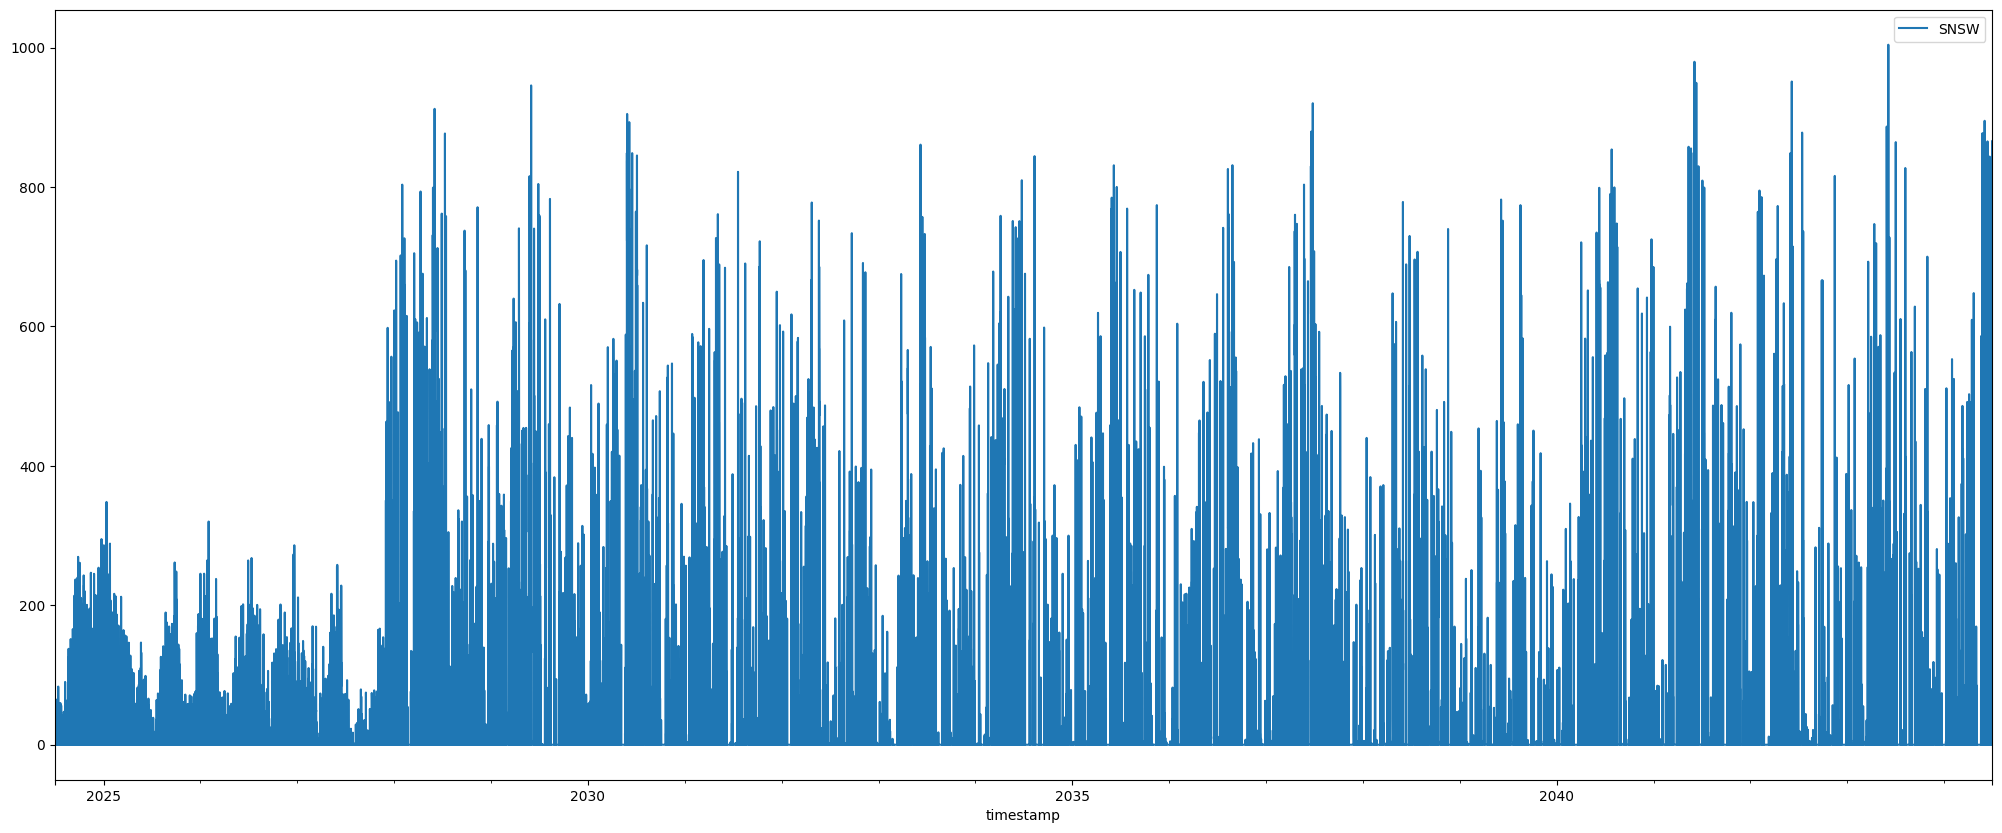

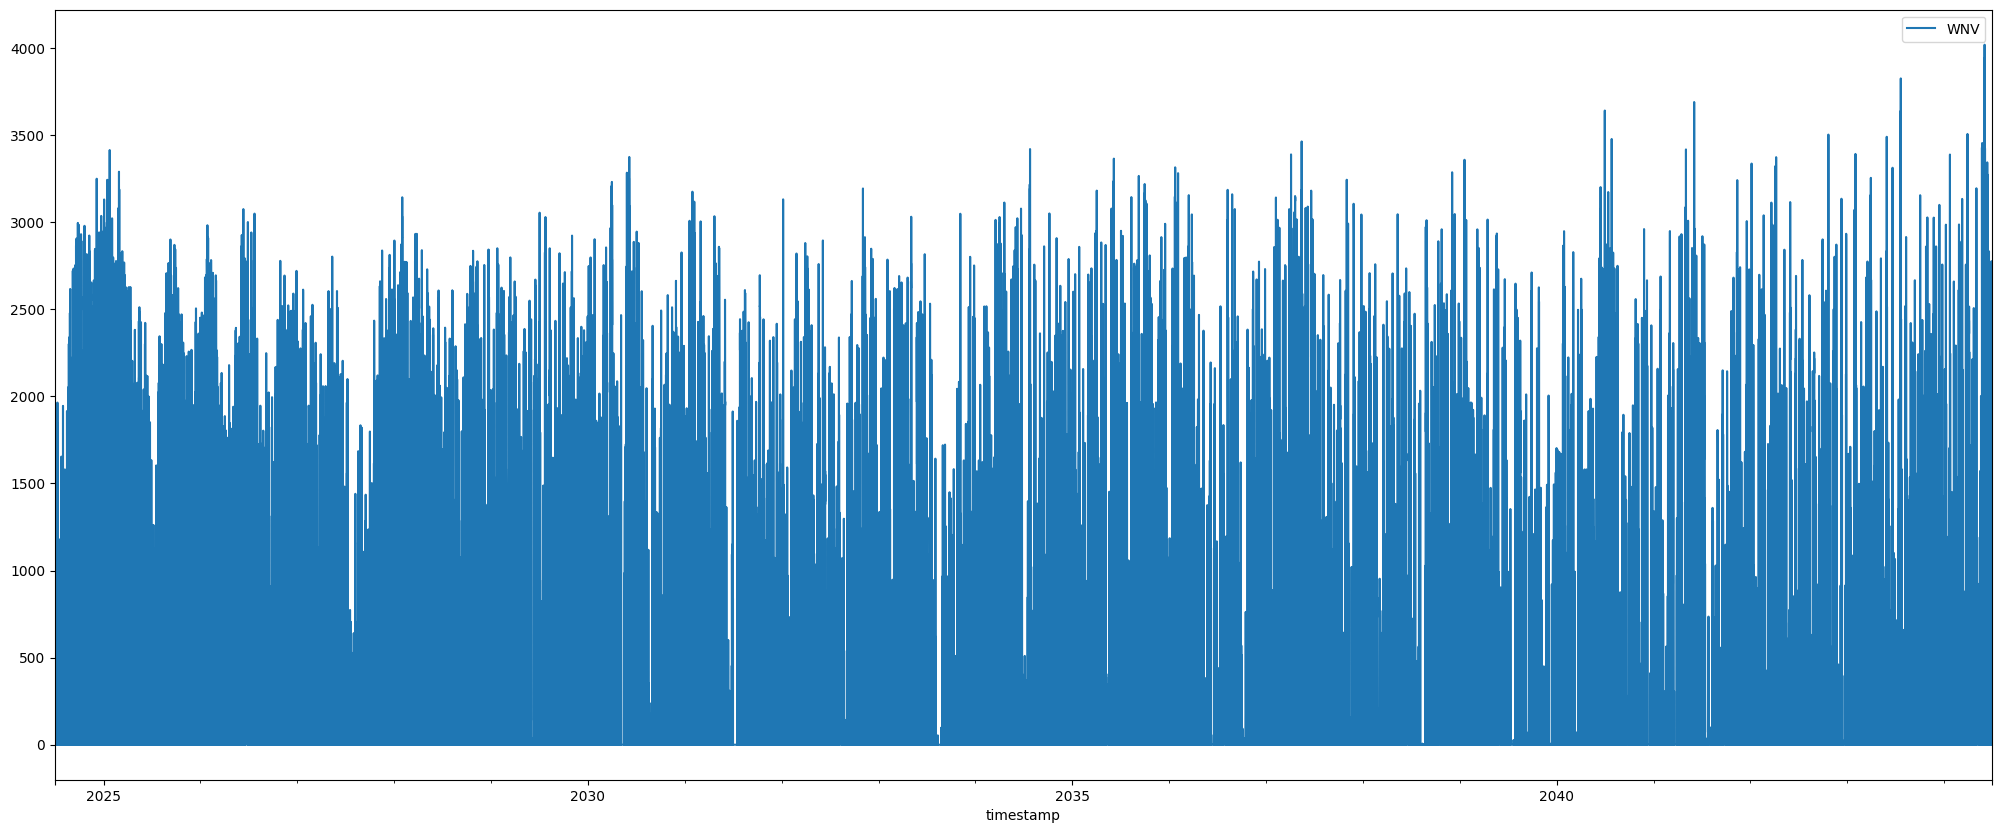

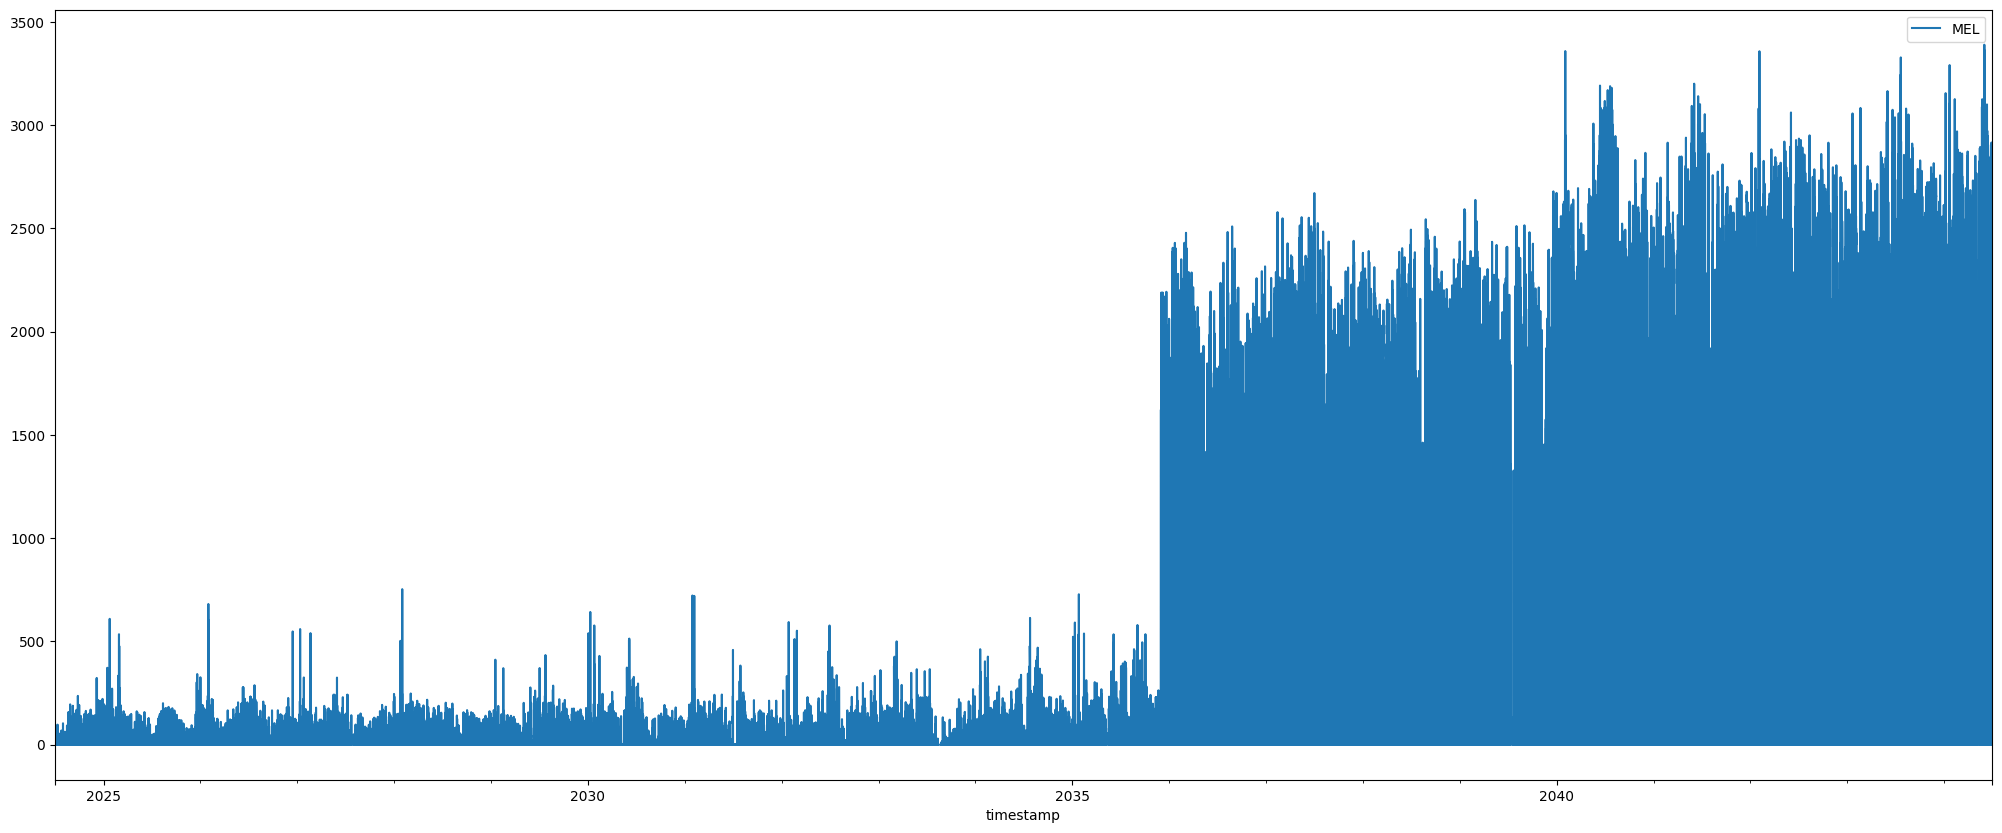

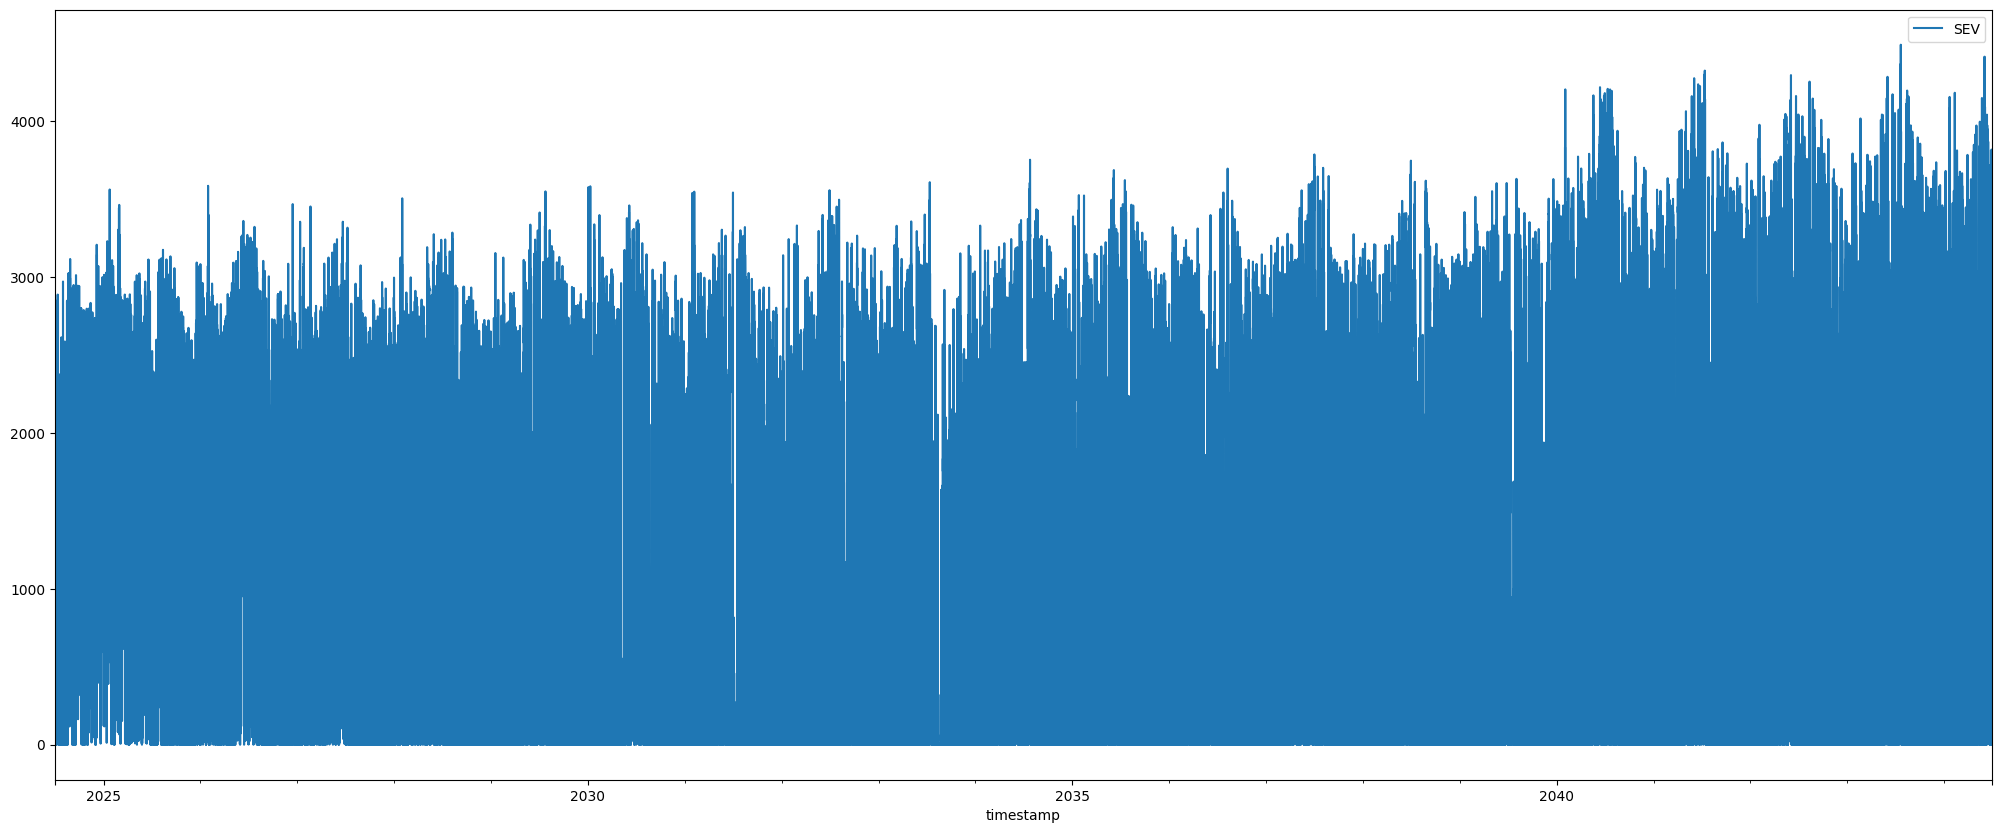

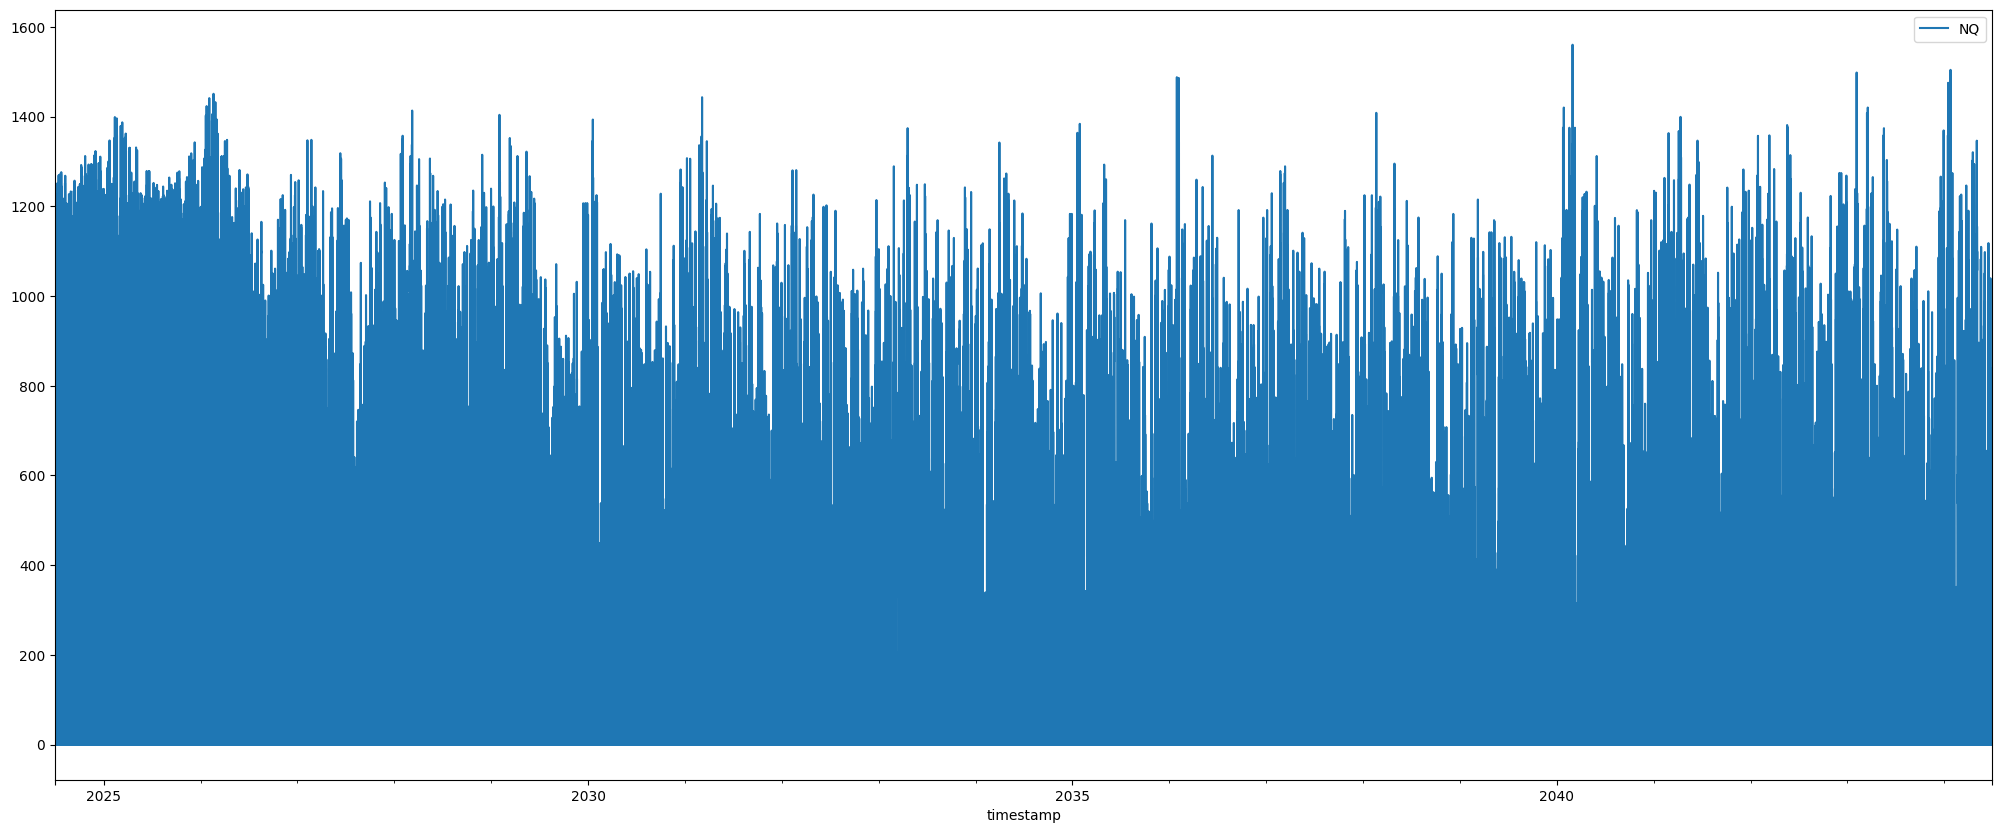

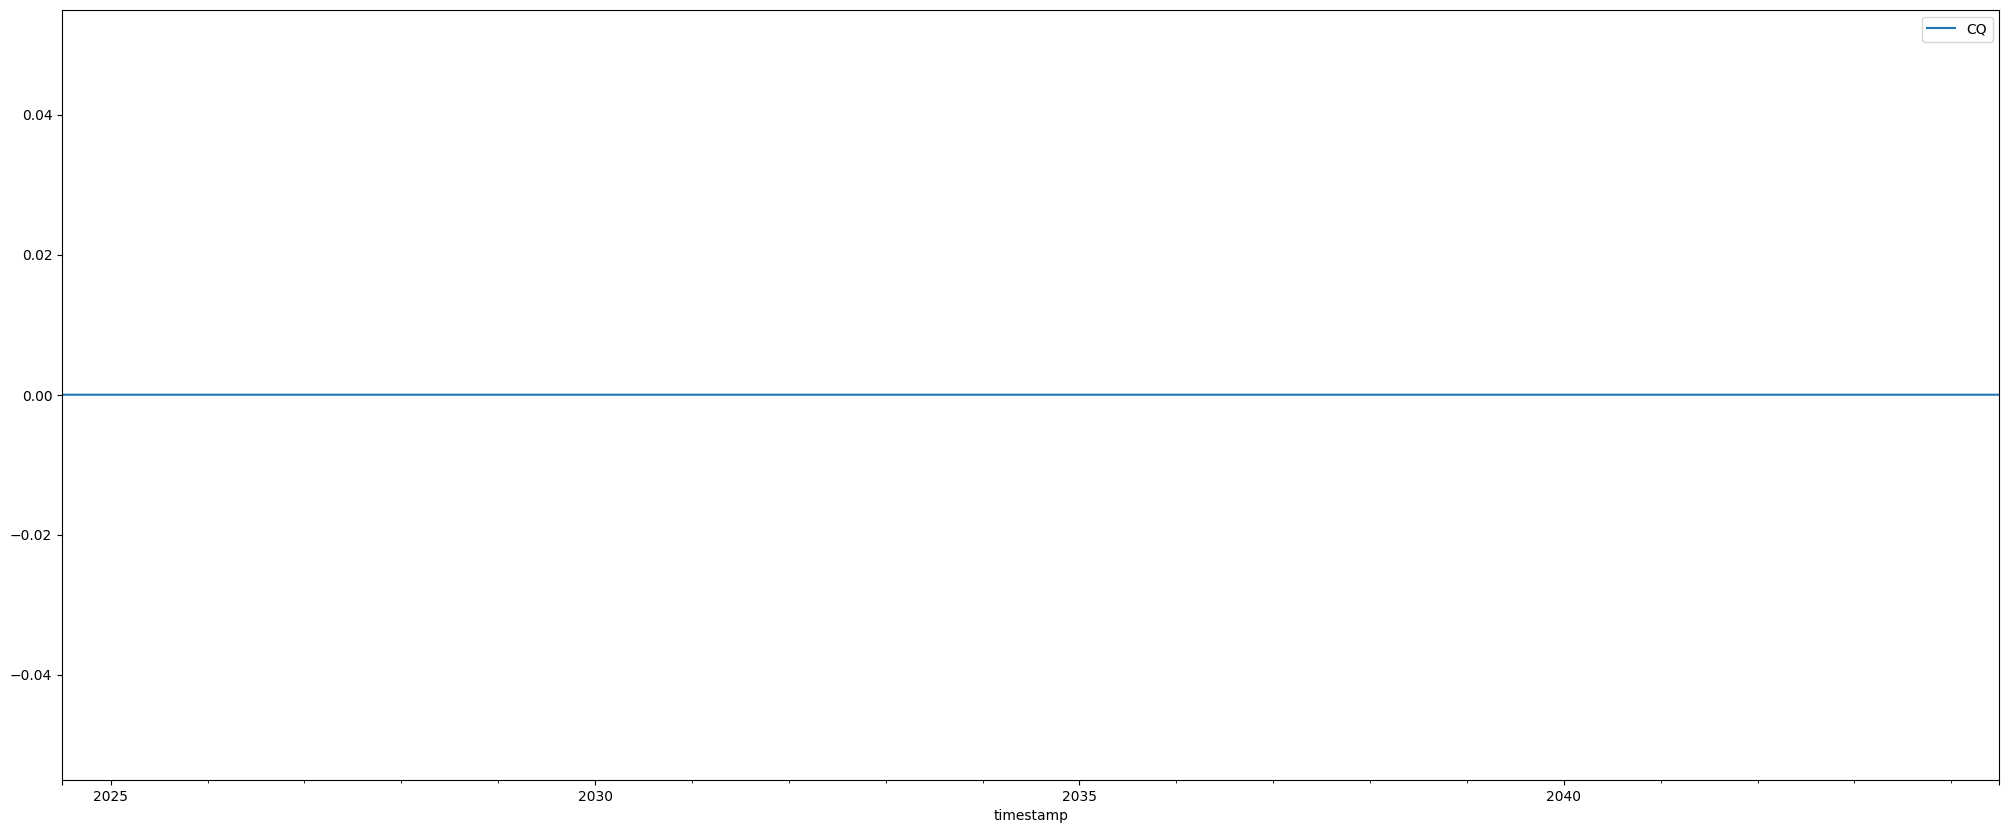

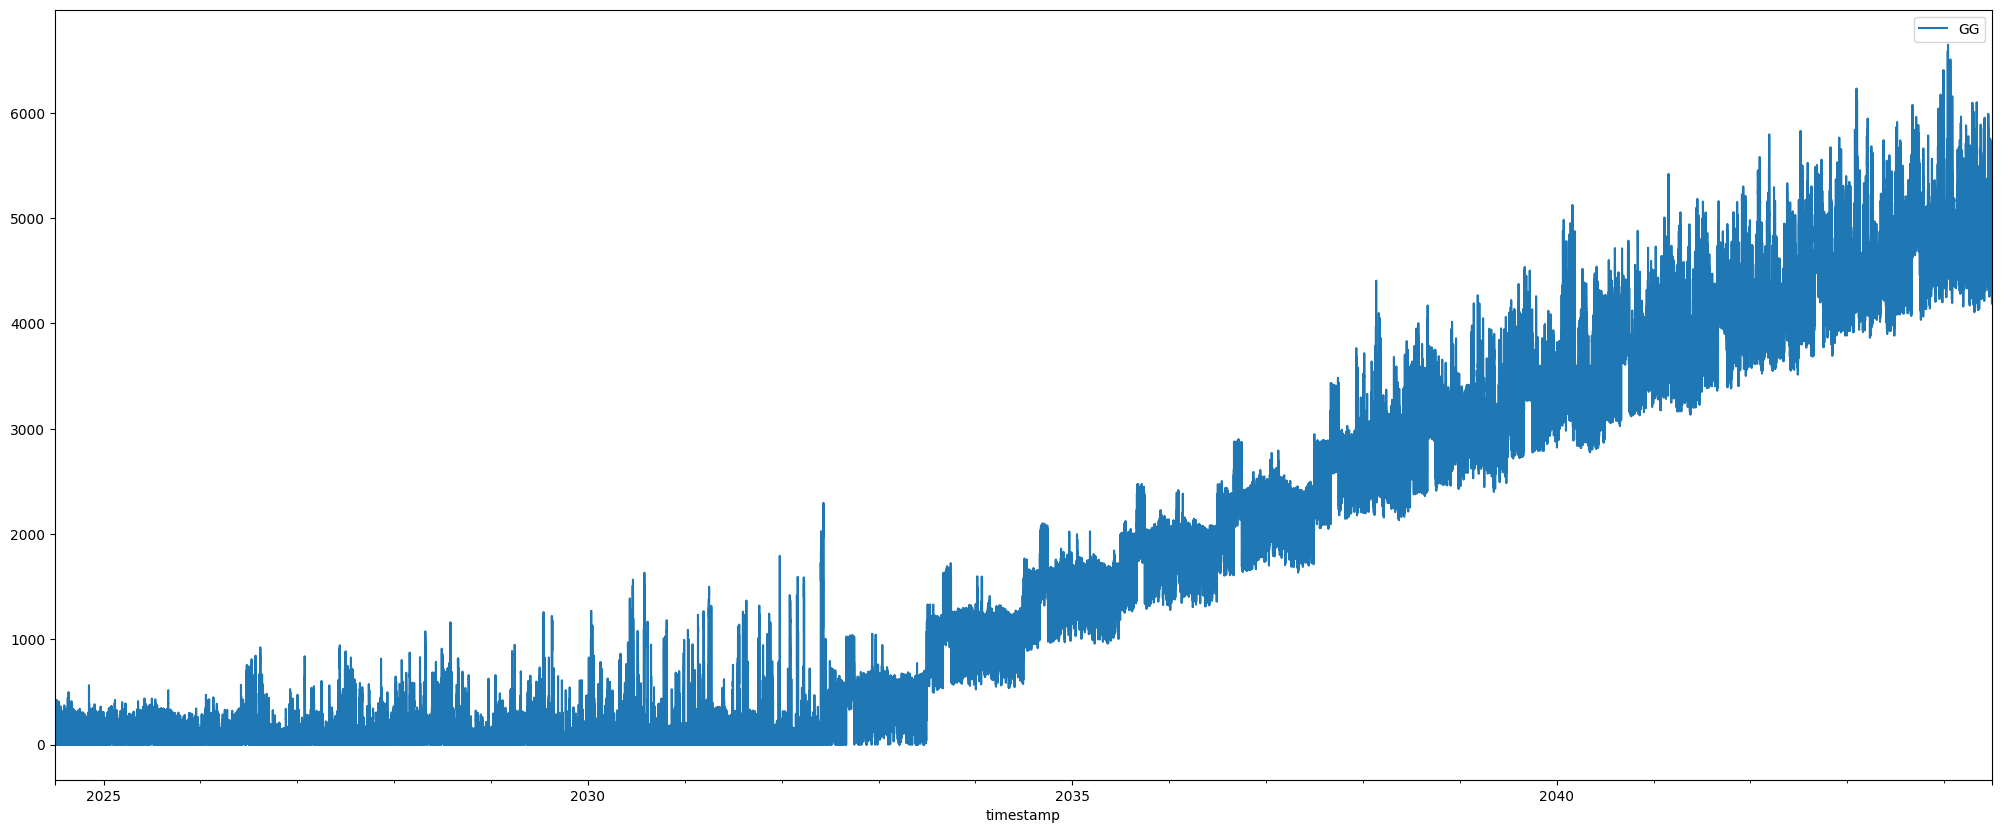

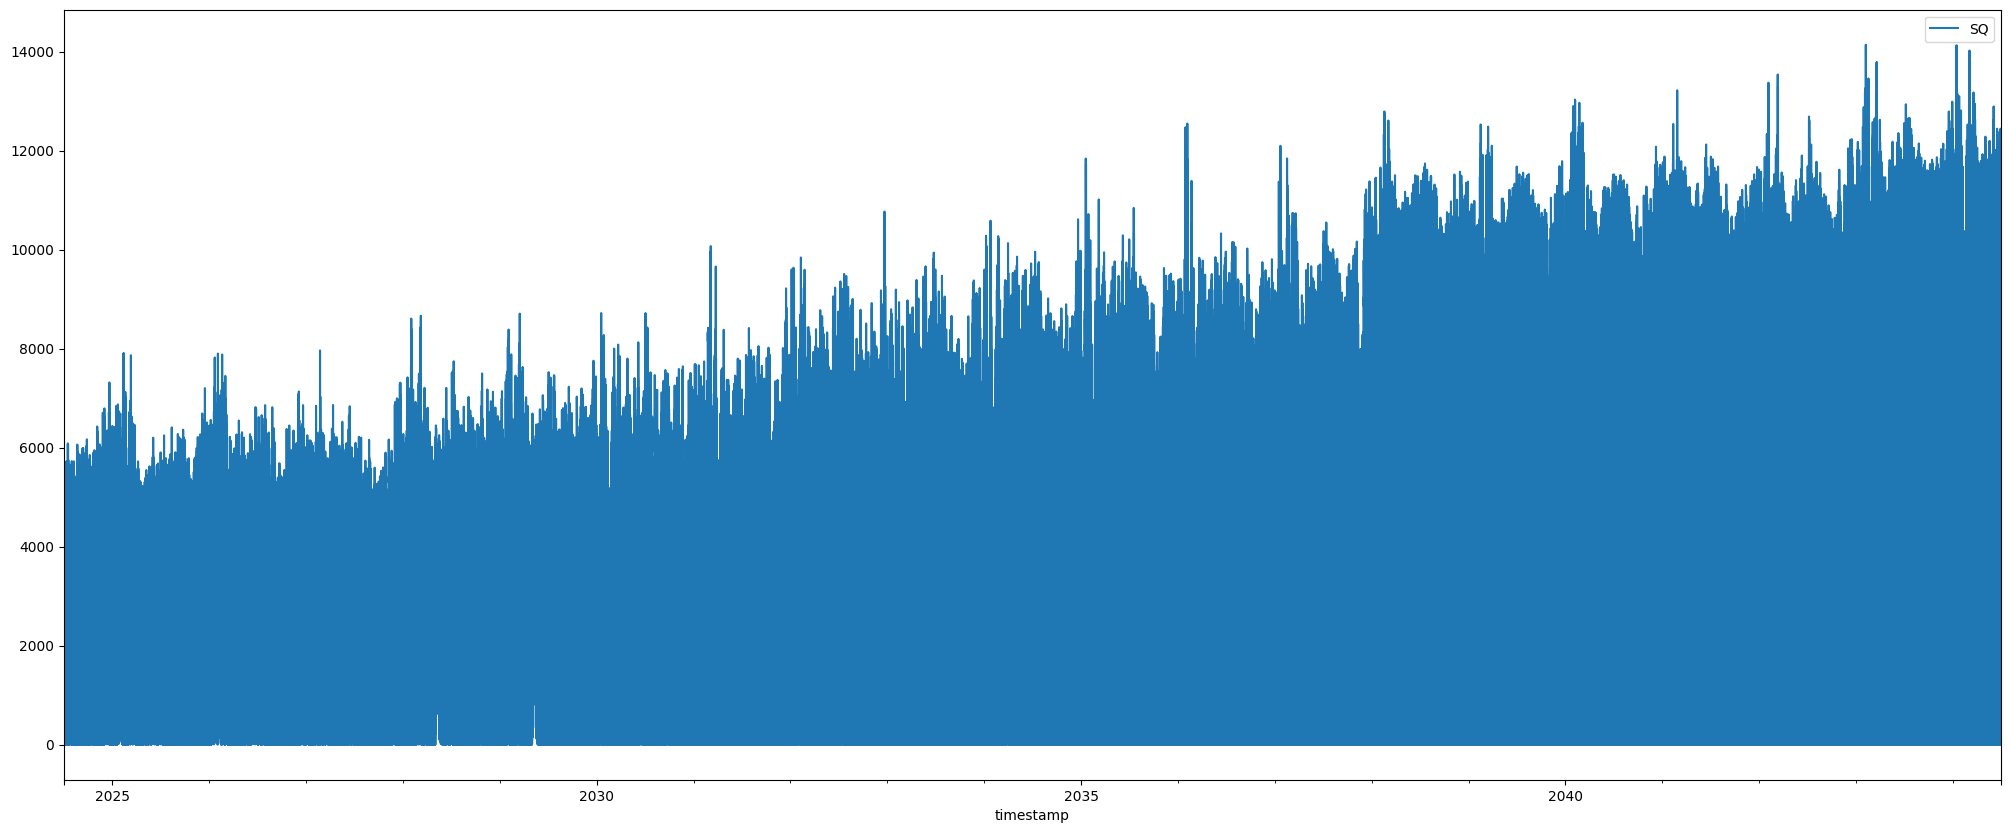

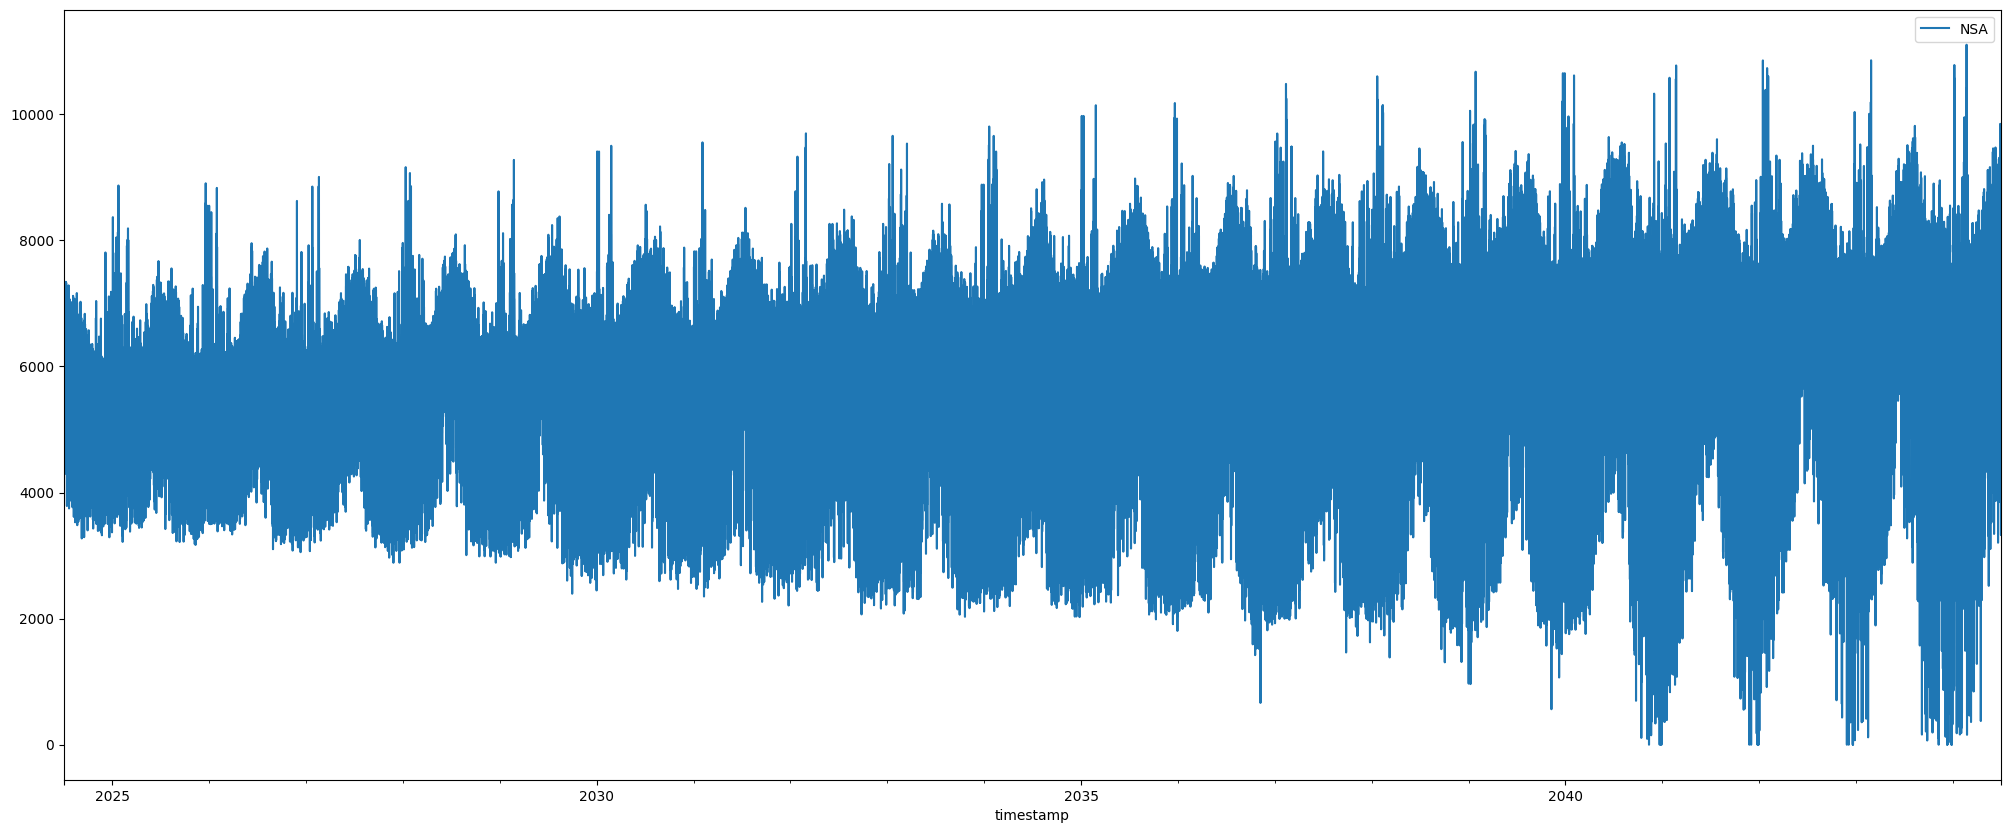

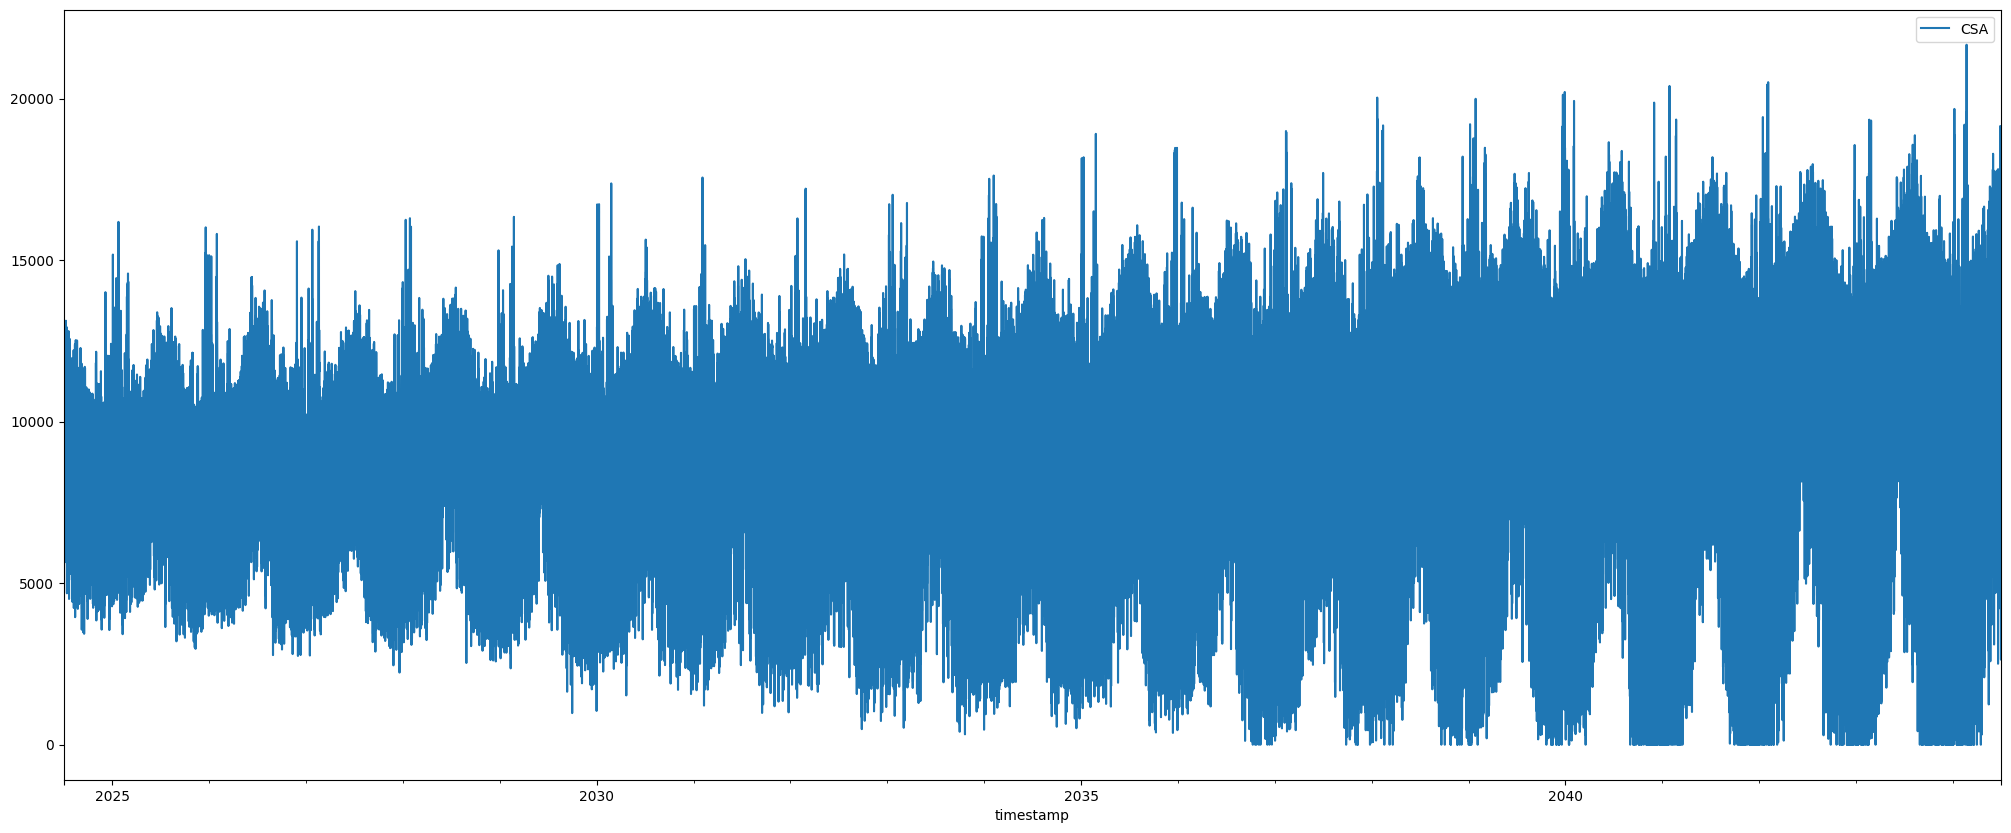

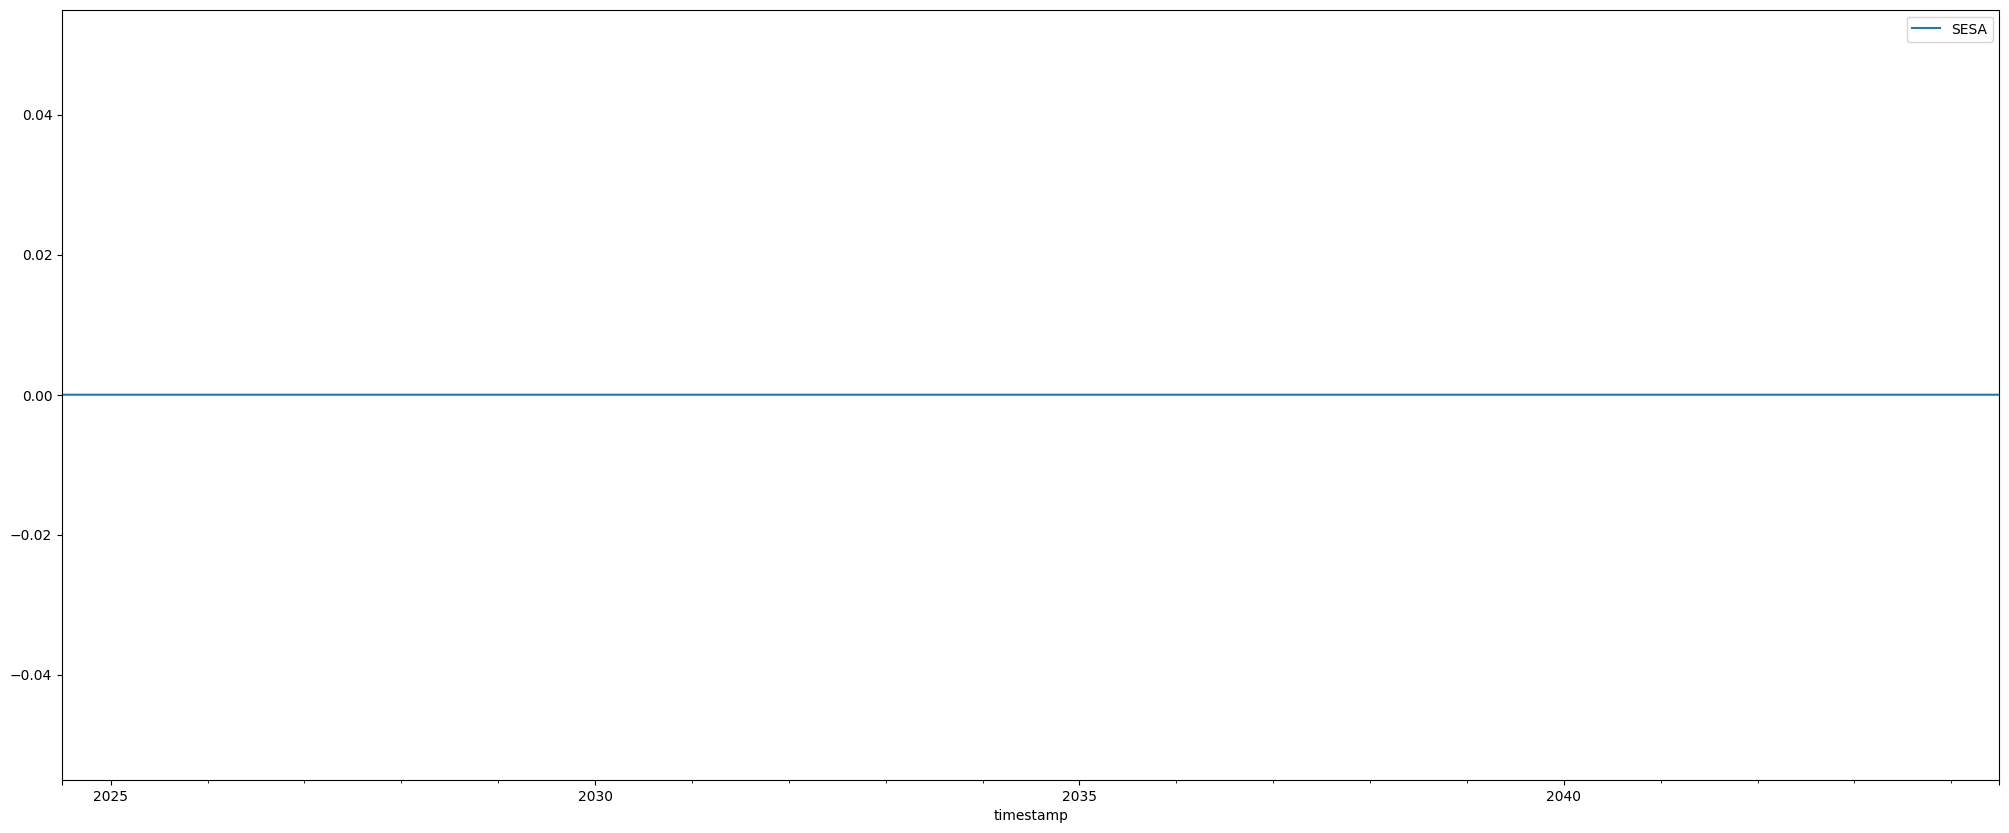

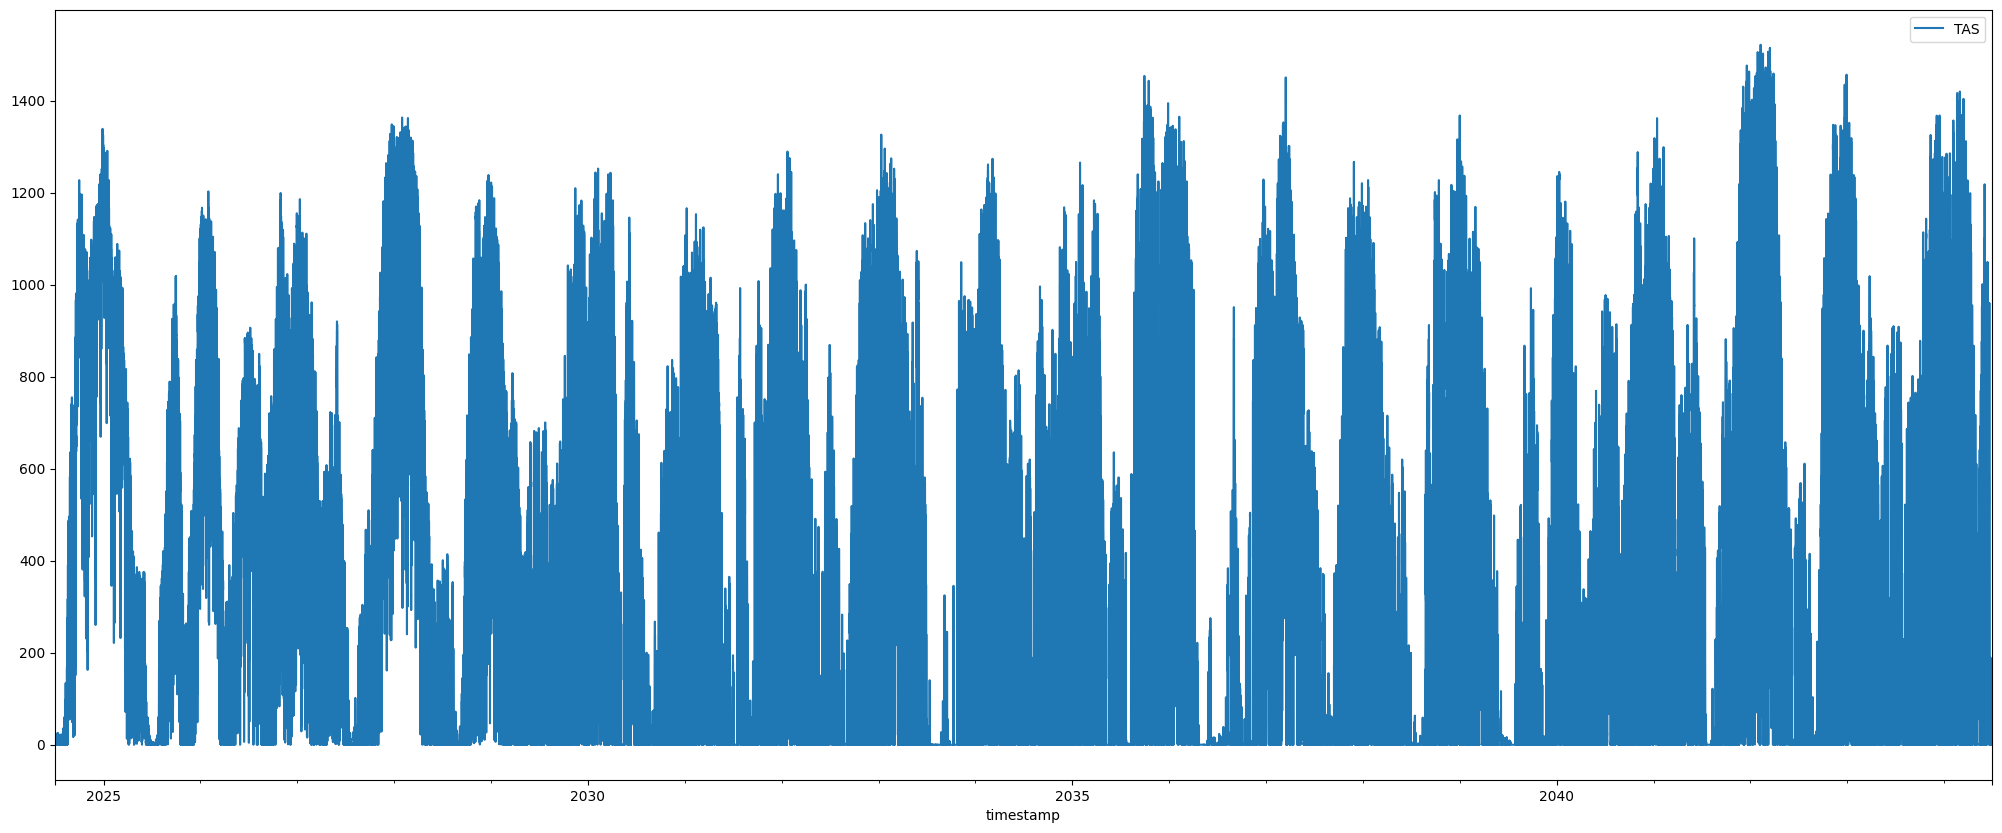

In [283]:
#fig, ax1 = plt.subplots(figsize=figsize, nrows=1, ncols=1)
#xx = eue_df.drop(columns=['SNW'])
for i, kk in enumerate(eue_df.columns):
    fig, ax1 = plt.subplots(figsize=figsize, nrows=1, ncols=1)
    eue_df[kk].plot(ax=ax1, legend=True)
    if i == 0:
        ax1.set_title("Expected Unserved Energy for each of the regions")
    
    

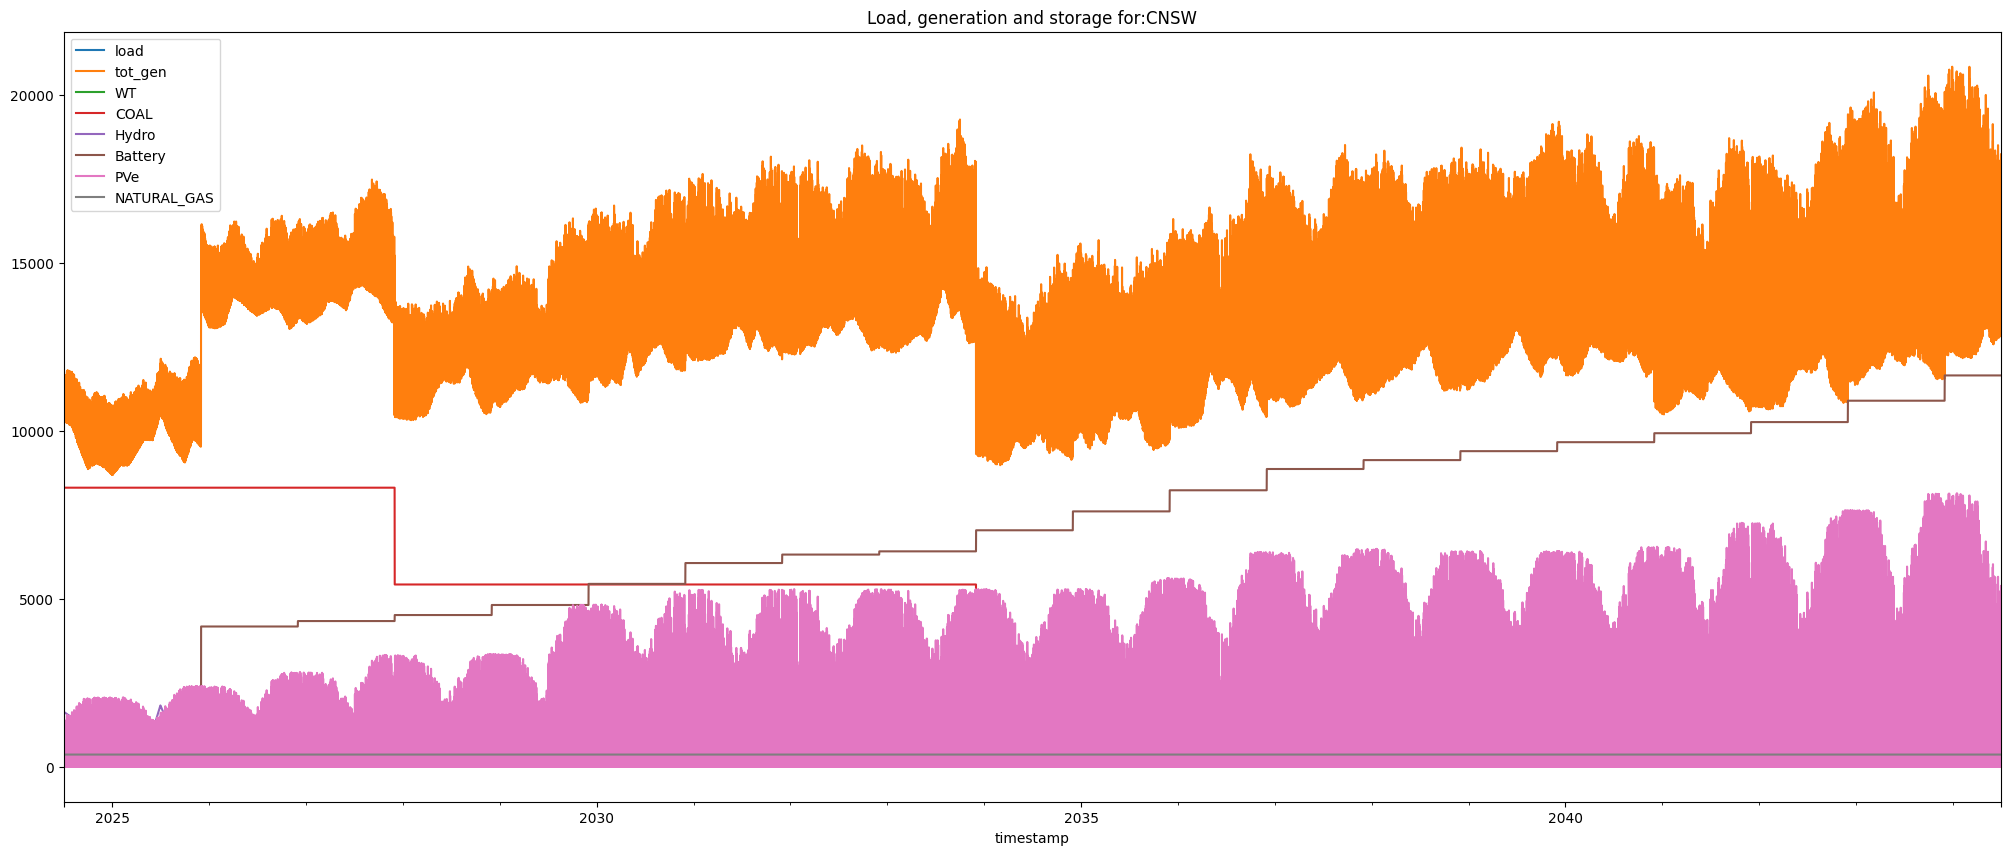

In [274]:

#eue_df = load_eue_shortfall(area_code_region, scenario)
target_region = "CNSW"  # "MEL"
flow_name = 'CNSW-SNW_mean_flow' # 'MEL-SEV_mean_flow'
st_date = '2024-7-1'
en_date = '2044-07-01'
get_all_info(target_region, shortfall_data, area_code_region)

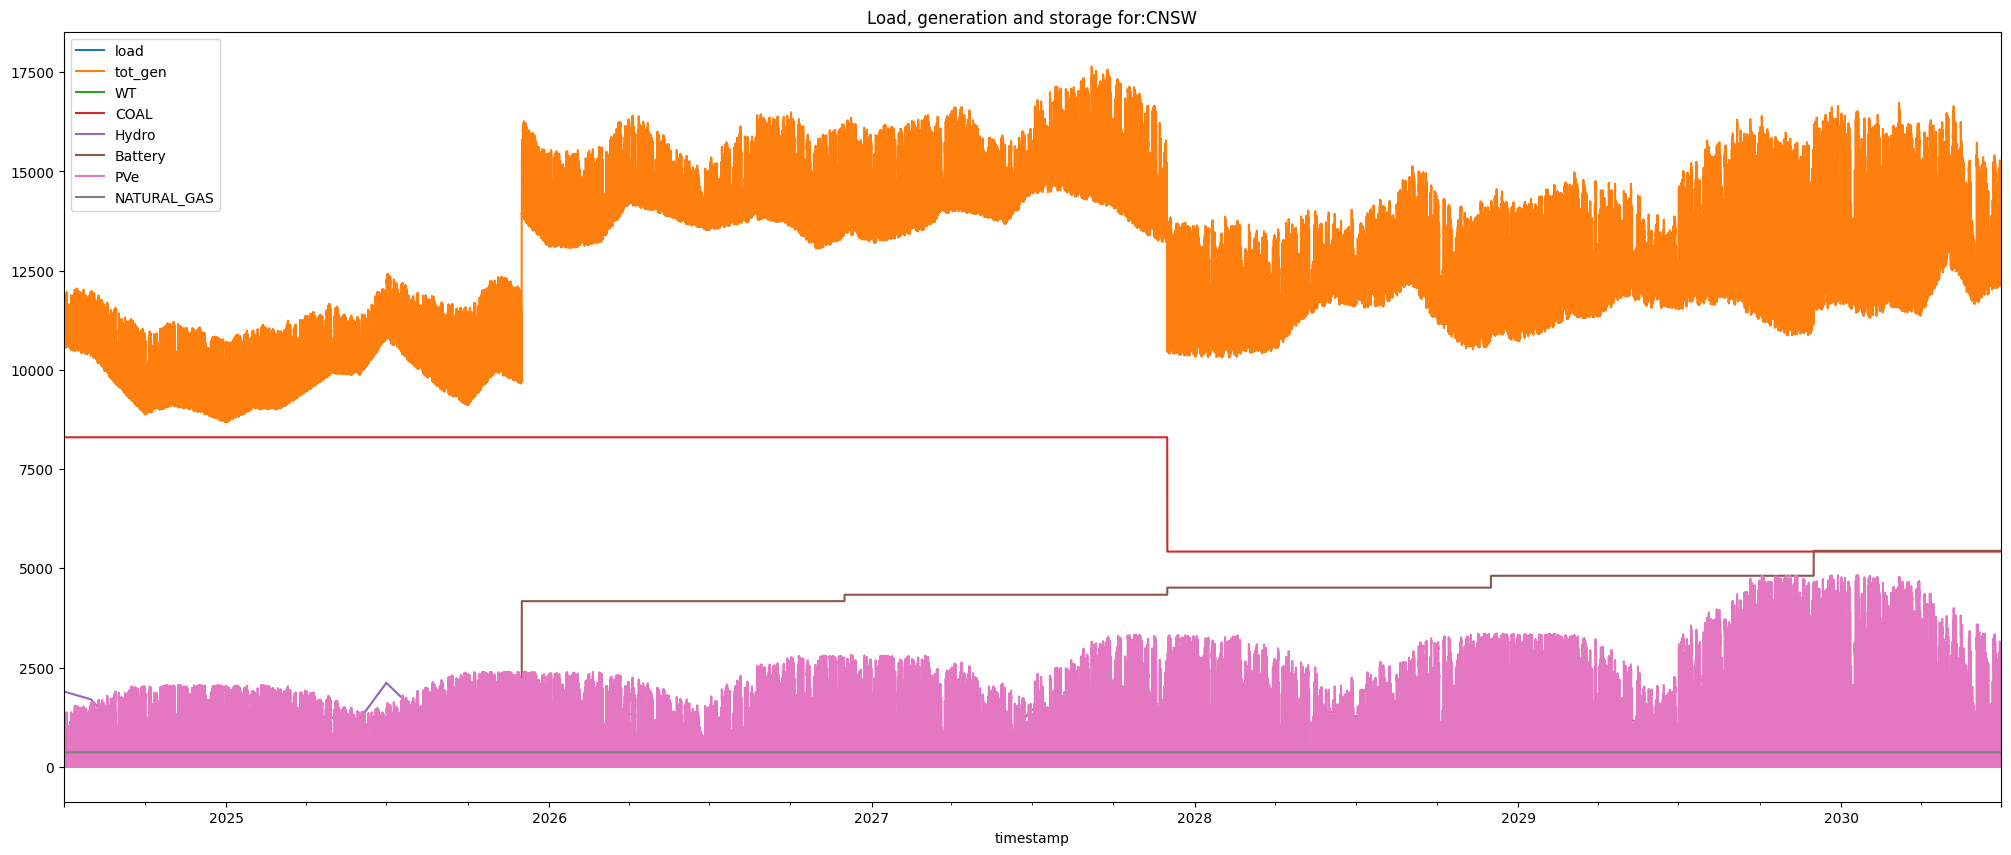

In [147]:
target_region = "CNSW"  # "MEL"
flow_name = 'CNSW-SNW_mean_flow' # 'MEL-SEV_mean_flow'
st_date = '2025-1-13'
en_date = '2030-07-01'
flow_for = flow_result(scenario, area_code_region)
comb_1, comb_2 = get_rel_data(shortfall_data, flow_for, storage, target_region, 
                              flow_name, st_date, en_date, area_code_region)
get_all_info(target_region, shortfall_data, area_code_region)

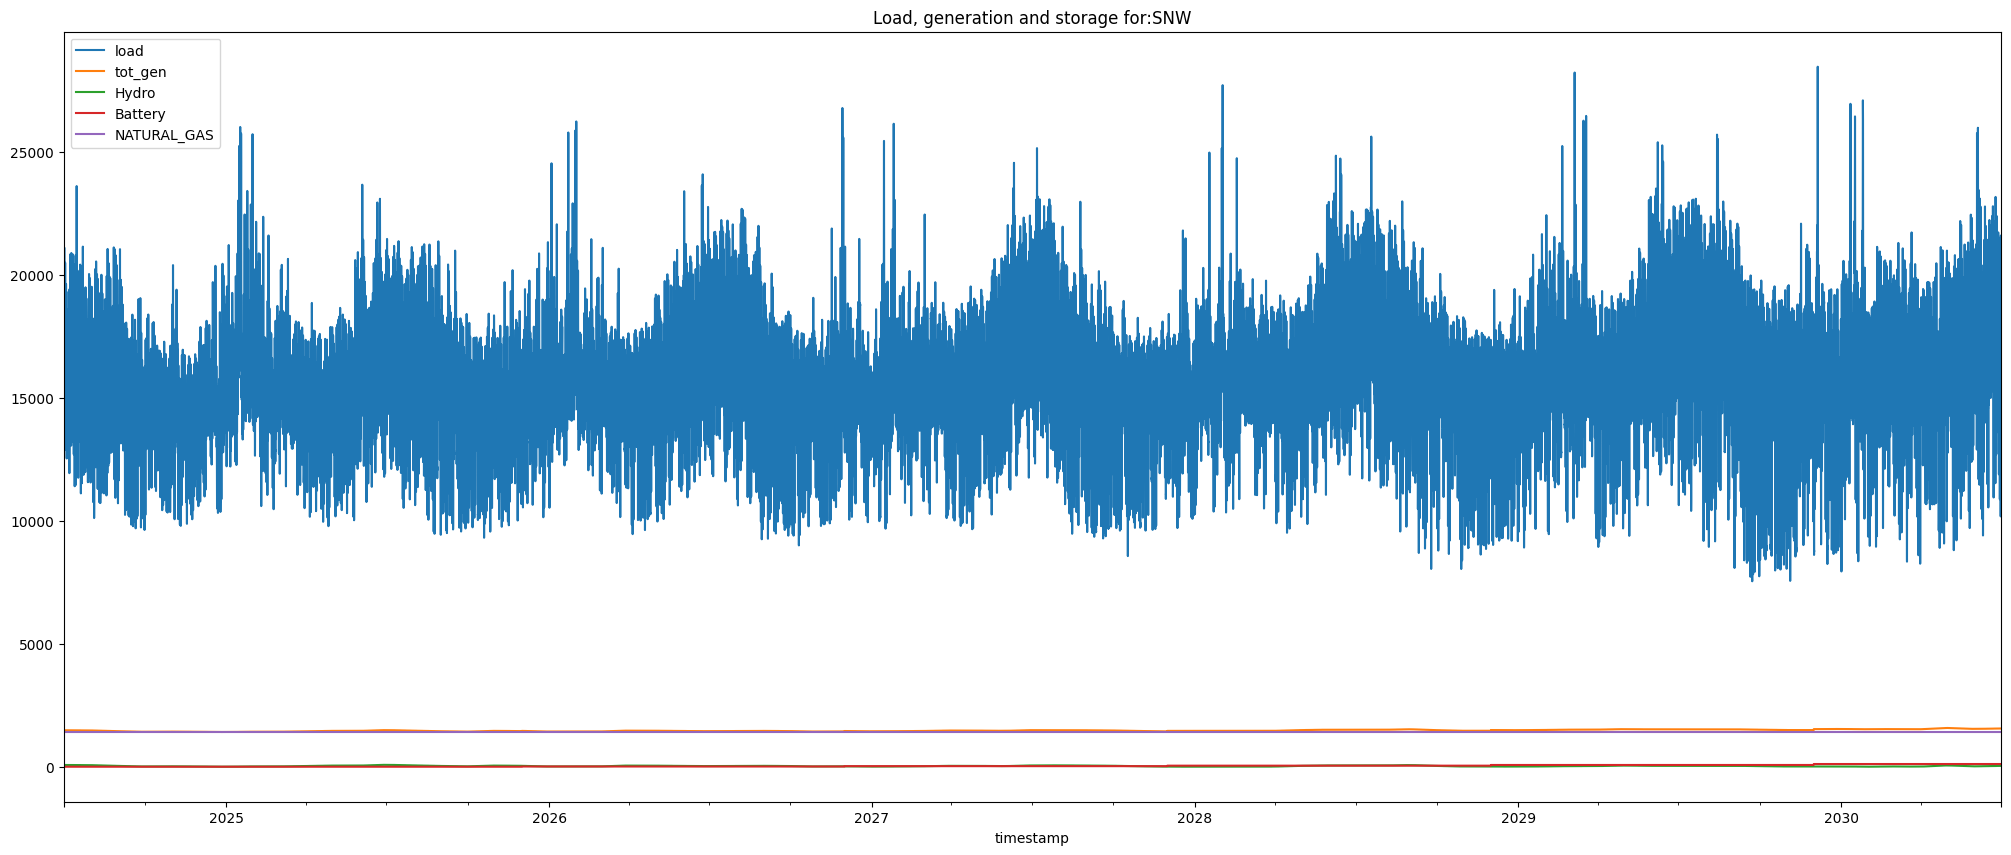

In [216]:
target_region = "SNW"  
flow_name = 'CNSW-SNW_mean_flow' 
st_date = '2025-1-13'
en_date = '2030-07-01'
flow_for = flow_result(scenario, area_code_region)
comb_1, comb_2 = get_rel_data(shortfall_data, flow_for, storage, target_region, 
                              flow_name, st_date, en_date, area_code_region)
get_all_info(target_region, shortfall_data, area_code_region)

<Axes: xlabel='timestamp'>

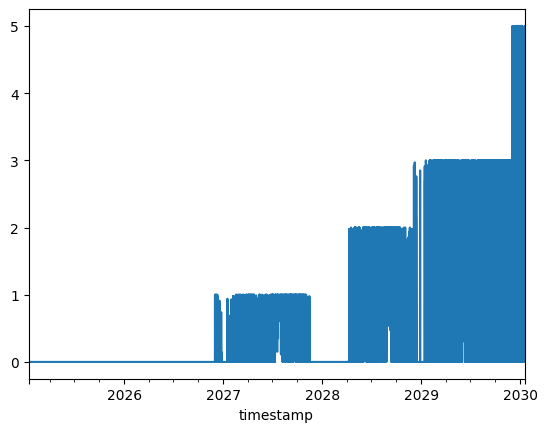

In [267]:
comb_1["agg_bat"].plot()

<Axes: xlabel='timestamp'>

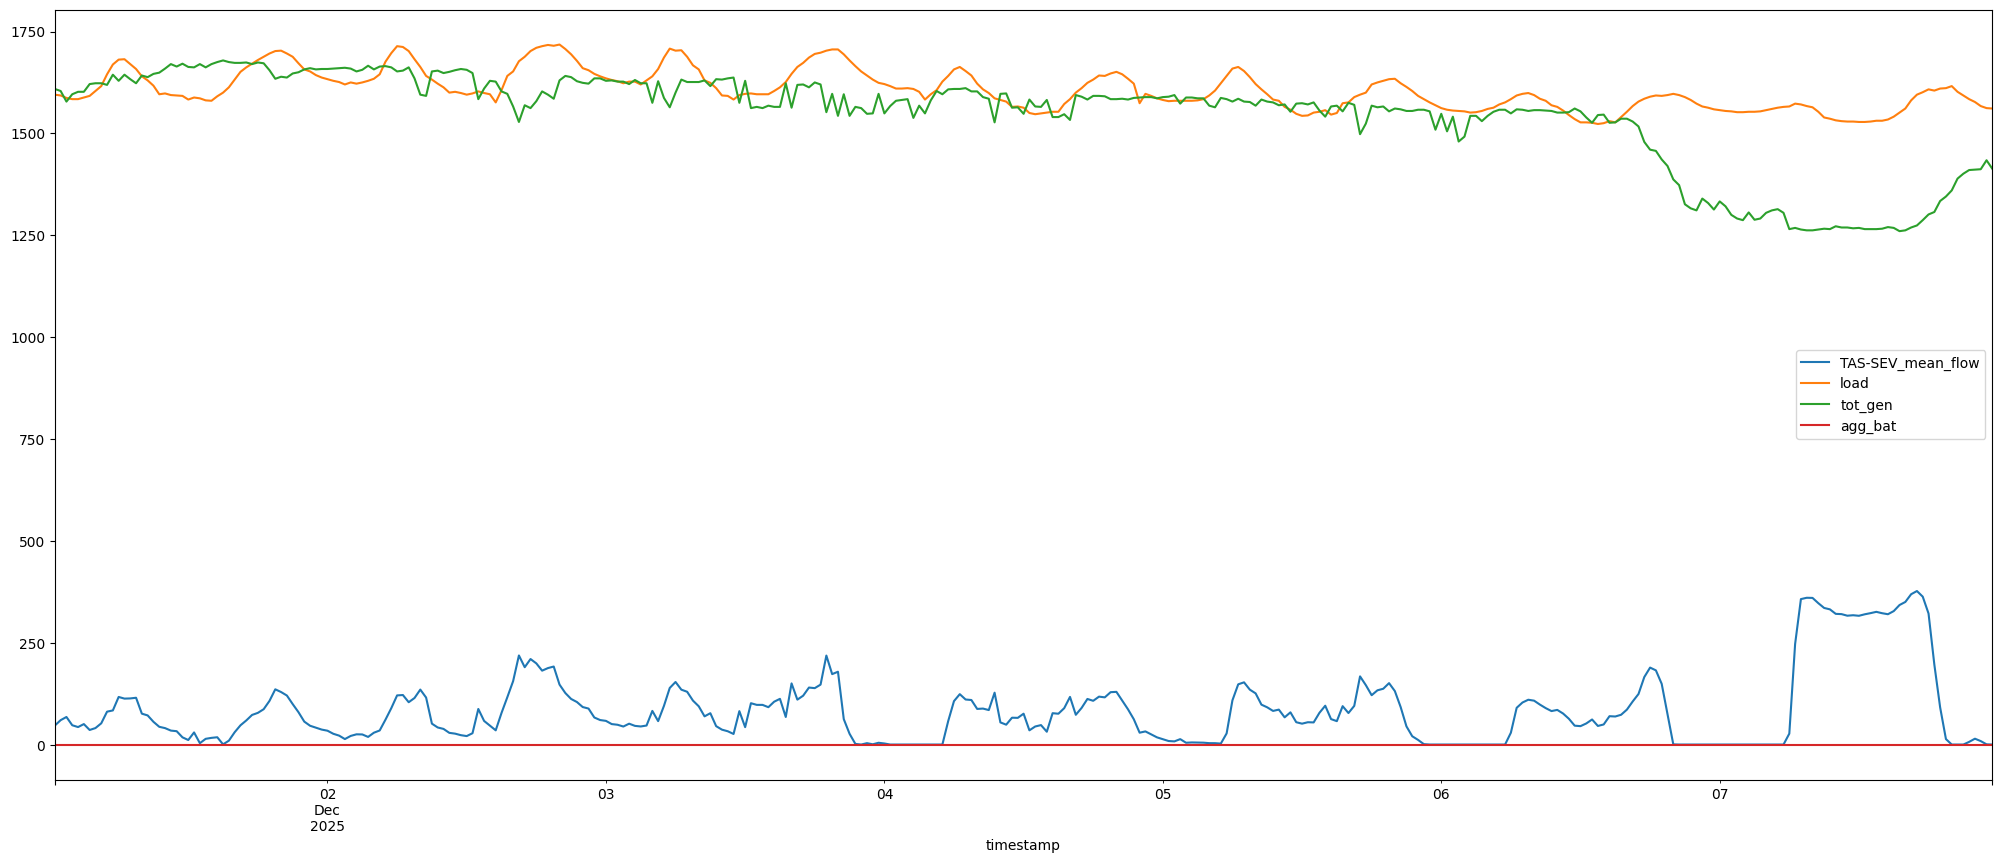

In [201]:
st_date = '2025-12-01'
en_date = '2025-12-08'
fig, ax1 = plt.subplots(figsize=figsize, nrows=1, ncols=1)
xx = comb_1[(comb_1.index > st_date) & (comb_1.index < en_date)]
yy = comb_2[(comb_2.index > st_date) & (comb_2.index < en_date)]
xx.plot(ax=ax1)

In [206]:
xx["load_gen_bal"] =  xx["tot_gen"] - xx["load"]

/tmp/bal246.52359/ipykernel_23548/2583775666.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xx["load_gen_bal"] =  xx["tot_gen"] - xx["load"]


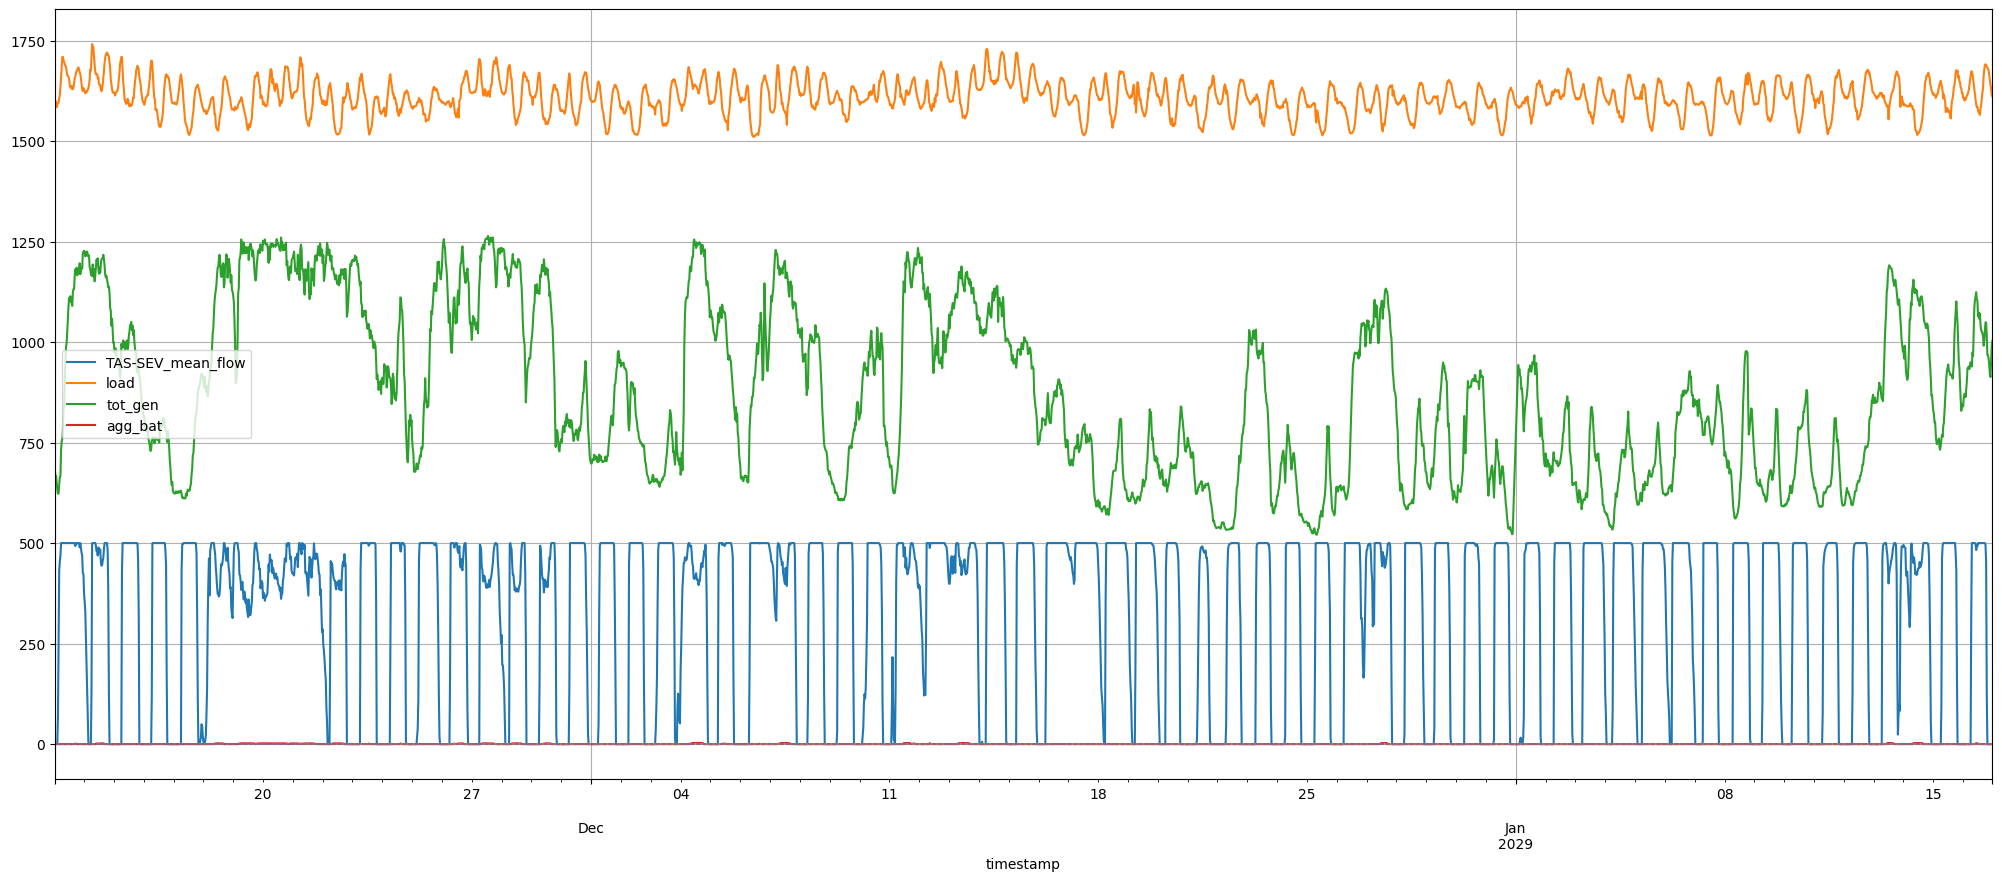

In [198]:
st_date = '2028-11-13'
en_date = '2029-1-17'
fig, ax1 = plt.subplots(figsize=figsize, nrows=1, ncols=1)
xx = comb_1[(comb_1.index > st_date) & (comb_1.index < en_date)]
yy = comb_2[(comb_2.index > st_date) & (comb_2.index < en_date)]
xx.plot(ax=ax1)
if yy is not None:
    yy.plot(ax=ax1, linestyle='--', linewidth=0.8, legend=False)
    title = ", generation incuding aggregated battery storages (all individual storages in dots), \n EUE and flow in " + flow_name
else:
    title = ", generation incuding EUE and flow in " + flow_name
#ax1.set_title("CSA load flow, generation and storage in mid Jan 2025") 
ax1.grid()

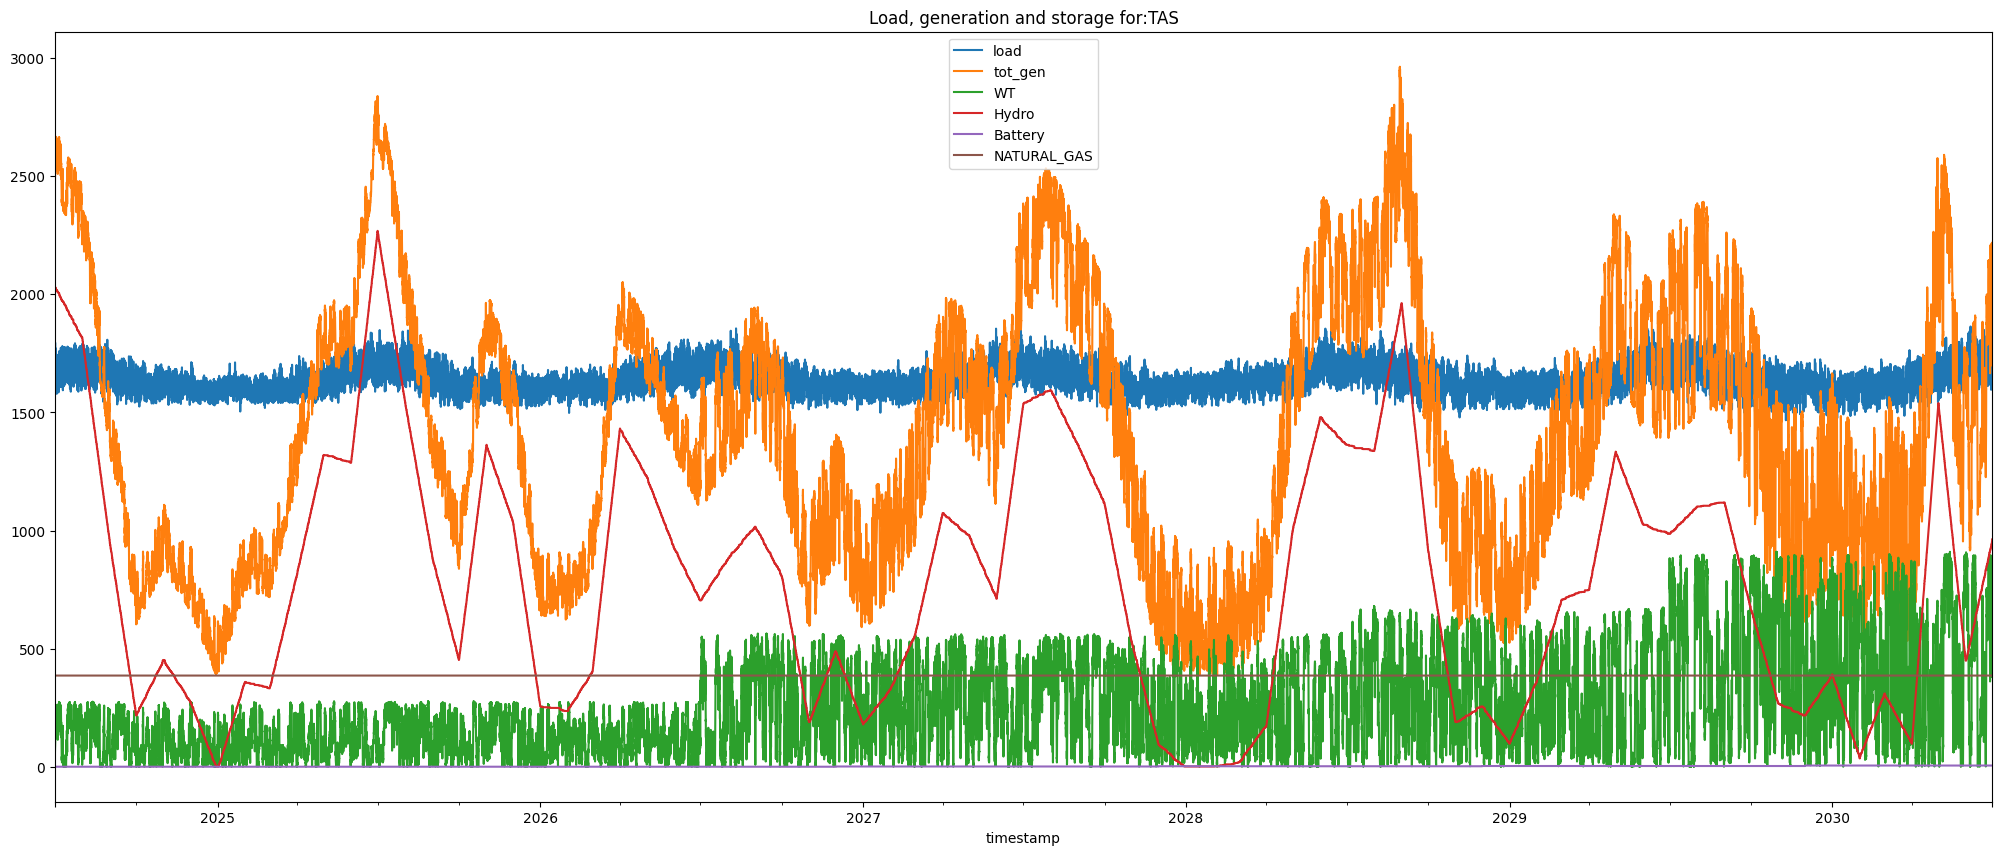

In [194]:
target_region = "TAS"  # "MEL"
flow_name = 'TAS-SEV_mean_flow' # 'MEL-SEV_mean_flow'
st_date = '2025-1-13'
en_date = '2030-07-01'
flow_for = flow_result(scenario, area_code_region)
comb_1, comb_2 = get_rel_data(shortfall_data, flow_for, storage, target_region, 
                              flow_name, st_date, en_date, area_code_region)
get_all_info(target_region, shortfall_data, area_code_region)

<Axes: xlabel='timestamp'>

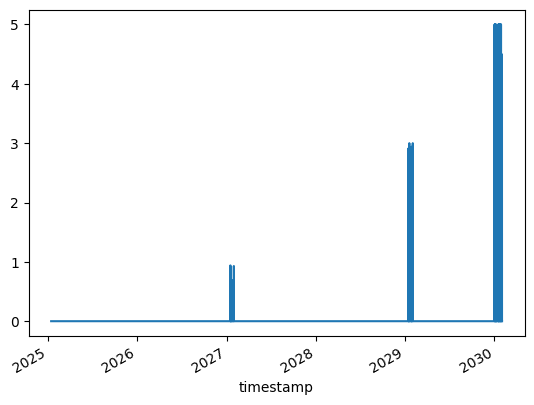

In [134]:
comb_1["agg_bat"].plot()

In [251]:
ts = pd.DataFrame(timestamps).set_index(0)
start_time = "2026-12-01"
end_time = "2027-01-15"
test_case_timestump = ts.loc[start_time:end_time]
test_case_timestump = test_case_timestump.index.tolist()
test_case_timestump = pd.to_datetime(test_case_timestump)

In [253]:
print("Scenario chosen: ", scenario)
timestamps = pd.to_datetime(shortfall_data["timestamps"], utc=True)
 
mean_shortfall_period(shortfall_data["region_results"], timestamps, test_case_timestump, area_code_region, eue_df)

Scenario chosen:  MT


ValueError: All arrays must be of the same length